In [200]:
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# NOTE

Abandone this dataset because it is too unrealistic

In [201]:
import pandas as pd
import os 
import numpy as np
from matplotlib import pyplot as plt 
import seaborn as sns
import math
from scipy import stats


In [202]:
# Set display to show all columns
pd.set_option('display.max_columns', None)

In [203]:
# import sys
# from pathlib import Path

# # from src.logging_history import logger
# from src.extractor.extract_function import extract_data_from_kaggle
# # Get project root (parent of notebook folder)
# project_root = Path.cwd().parent
# sys.path.insert(0, str(project_root))
# print(f"project_root: ", {project_root})




In [204]:
kaggle_dataset_name = "rayzem/dynamic-apparel-sales-dataset-with-anomalies"

# file_path = extract_data_from_kaggle(kaggle_dataset_name)

In [205]:
file_path = r"C:\Users\minhtam.nguyen\.cache\kagglehub\datasets\rayzem\dynamic-apparel-sales-dataset-with-anomalies\versions\1\Multiclass Clothing Sales Dataset.csv"

In [206]:
df = pd.read_csv(file_path)
df.head(3)

,Product_Category,Brand,Product_Name,Gender,Size,Color,Season,Payment_Method,Customer_Type,Selling_Price,Cost_Price,Discount_Percentage,Quantity_Sold,Total_Sales,Stock_Availability,Customer_Age,Purchase_Frequency,Store_Rating,Return_Rate,Sales_Category
0,Traditional Wear,Forever 21,Tops,Women,S,White,Winter,Card,New,1817.433878,816.027585,26.260791,6,42241.692855,294.0,58.0,2.560957,3.106155,29.293331,High Sales
1,Athleisure,Ralph Lauren,Casual Shirt,Men,XXL,Yellow,All-Season,Card,Returning,1672.038198,793.236861,26.882613,8,69318.541482,376.0,40.0,1.590993,3.428439,19.473670,Low Sales
2,Outerwear,Nike,Blazer,Men,S,Green,All-Season,UPI,Returning,1381.568069,890.469629,30.274720,5,56851.121070,48.0,41.0,3.066213,3.765591,22.083407,Medium Sales


In [207]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Product_Category     100000 non-null  object 
 1   Brand                100000 non-null  object 
 2   Product_Name         100000 non-null  object 
 3   Gender               100000 non-null  object 
 4   Size                 100000 non-null  object 
 5   Color                100000 non-null  object 
 6   Season               100000 non-null  object 
 7   Payment_Method       100000 non-null  object 
 8   Customer_Type        100000 non-null  object 
 9   Selling_Price        95000 non-null   float64
 10  Cost_Price           100000 non-null  float64
 11  Discount_Percentage  95000 non-null   float64
 12  Quantity_Sold        100000 non-null  int64  
 13  Total_Sales          100000 non-null  float64
 14  Stock_Availability   95000 non-null   float64
 15  Customer_Age      

In [208]:
df['Brand'].value_counts()

Brand
Wrangler          5134
Ralph Lauren      5102
Forever 21        5075
H&M               5064
Nike              5045
Levi’s            5036
Adidas            5011
Versace           5010
Zara              5007
Tommy Hilfiger    4997
Calvin Klein      4994
Under Armour      4993
Uniqlo            4985
GAP               4984
Diesel            4980
Louis Vuitton     4980
Gucci             4953
Reebok            4922
Puma              4877
Balenciaga        4851
Name: count, dtype: int64

In [209]:
df.describe()

,Selling_Price,Cost_Price,Discount_Percentage,Quantity_Sold,Total_Sales,Stock_Availability,Customer_Age,Purchase_Frequency,Store_Rating,Return_Rate
count,95000.000000,100000.000000,95000.000000,100000.000000,100000.000000,95000.000000,95000.000000,100000.000000,95000.000000,100000.000000
mean,1554.029505,1041.472376,24.994389,5.348760,50051.437498,250.329842,41.066821,2.081108,3.995121,14.956974
std,974.709187,734.619046,14.431100,7.215449,20076.412144,144.472592,13.567101,1.896919,0.586217,8.651961
min,-613.615890,-726.934992,0.000127,1.000000,-37155.408729,0.000000,18.000000,-2.096379,1.002394,0.000492
25%,1162.144173,732.336452,12.447380,3.000000,36596.251916,126.000000,29.000000,1.327364,3.497587,7.435705
50%,1501.409850,1005.567011,25.007454,5.000000,50115.894604,251.000000,41.000000,2.001746,3.995872,14.960901
75%,1842.752501,1276.944645,37.450829,7.000000,63504.829774,376.000000,53.000000,2.685177,4.497780,22.440826
max,19989.216427,14992.757159,49.999563,199.000000,141640.191523,499.000000,64.000000,49.000000,4.999984,29.999077


# EDA

In [210]:
df.isnull().sum()

Product_Category          0
Brand                     0
Product_Name              0
Gender                    0
Size                      0
Color                     0
Season                    0
Payment_Method            0
Customer_Type             0
Selling_Price          5000
Cost_Price                0
Discount_Percentage    5000
Quantity_Sold             0
Total_Sales               0
Stock_Availability     5000
Customer_Age           5000
Purchase_Frequency        0
Store_Rating           5000
Return_Rate               0
Sales_Category            0
dtype: int64

## Missing values

In [211]:
dfclean = df.dropna()
dfclean.shape

(77298, 20)

In [212]:
dfclean.head()

,Product_Category,Brand,Product_Name,Gender,Size,Color,Season,Payment_Method,Customer_Type,Selling_Price,Cost_Price,Discount_Percentage,Quantity_Sold,Total_Sales,Stock_Availability,Customer_Age,Purchase_Frequency,Store_Rating,Return_Rate,Sales_Category
0,Traditional Wear,Forever 21,Tops,Women,S,White,Winter,Card,New,1817.433878,816.027585,26.260791,6,42241.692855,294.0,58.0,2.560957,3.106155,29.293331,High Sales
1,Athleisure,Ralph Lauren,Casual Shirt,Men,XXL,Yellow,All-Season,Card,Returning,1672.038198,793.236861,26.882613,8,69318.541482,376.0,40.0,1.590993,3.428439,19.473670,Low Sales
2,Outerwear,Nike,Blazer,Men,S,Green,All-Season,UPI,Returning,1381.568069,890.469629,30.274720,5,56851.121070,48.0,41.0,3.066213,3.765591,22.083407,Medium Sales
6,Outerwear,Wrangler,Hoodie,Men,M,White,All-Season,UPI,Returning,1191.442375,1159.158217,31.015017,5,15947.662532,387.0,47.0,1.083173,3.144731,6.338736,High Sales
7,Outerwear,Zara,Jumpsuit,Women,XL,Orange,Winter,Card,Returning,296.437161,1656.010130,6.067290,6,54267.969945,56.0,60.0,2.992408,3.185068,0.913214,Medium Sales


## Treating

# Remove Dup

In [213]:
dfclean.columns

Index(['Product_Category', 'Brand', 'Product_Name', 'Gender', 'Size', 'Color',
       'Season', 'Payment_Method', 'Customer_Type', 'Selling_Price',
       'Cost_Price', 'Discount_Percentage', 'Quantity_Sold', 'Total_Sales',
       'Stock_Availability', 'Customer_Age', 'Purchase_Frequency',
       'Store_Rating', 'Return_Rate', 'Sales_Category'],
      dtype='object')

In [214]:
dfclean= dfclean[[ 'Brand', 'Product_Name', 'Gender', 'Size', 'Color',
       'Season',  'Selling_Price', 'Cost_Price', 'Discount_Percentage', 'Quantity_Sold', 
       'Stock_Availability',  'Purchase_Frequency', 'Return_Rate']].drop_duplicates()

## Add columns

In [215]:

dfclean['Selling_Price'] = np.absolute(dfclean['Selling_Price'])
dfclean['Cost_Price'] = np.absolute(dfclean['Cost_Price'])

In [216]:
dfclean['Total_Cost'] = dfclean['Cost_Price'] * dfclean['Quantity_Sold']
dfclean['Total_Sales2'] = dfclean['Selling_Price'] * dfclean['Quantity_Sold'] * (1- dfclean['Discount_Percentage']/100)

In [217]:
dfclean['Unit_Profit'] = dfclean['Selling_Price']  - dfclean['Cost_Price']
dfclean['Unit_Margin'] = dfclean['Unit_Profit'] / dfclean['Selling_Price'] 

dfclean['Profit']  = dfclean['Total_Sales2'] - dfclean['Total_Cost']
dfclean['Margin'] = dfclean['Profit'] / dfclean['Total_Sales2']


## Only a brand

In [218]:
dfclean.pivot_table(
        index=['Brand', 'Product_Name'],values='Cost_Price' ,aggfunc=['mean', 'min', 'max', 'std', 'quantile', 'skew']
        ).reset_index()

,Brand,Product_Name,mean,min,max,std,quantile,skew
,,,Cost_Price,Cost_Price,Cost_Price,Cost_Price,Cost_Price,Cost_Price
0,Adidas,Blazer,1094.580167,84.892130,8686.109978,658.875139,1042.870553,8.005276
1,Adidas,Casual Shirt,1057.984149,73.026315,11343.899904,875.099697,1021.660035,9.462827
2,Adidas,Dress,1044.950555,55.381012,14510.216921,1014.130191,986.657291,11.453023
3,Adidas,Formal Shirt,1122.036158,19.155995,13729.764179,1300.427816,927.976280,7.447178
4,Adidas,Hoodie,1135.590077,104.683329,13860.044159,1305.823403,1024.233814,8.535239
...,...,...,...,...,...,...,...,...
395,Zara,Sweatshirt,1086.262474,37.189741,13329.919373,997.834049,1053.528079,10.278726
396,Zara,T-Shirt,1019.920255,105.728199,10161.683427,830.690046,919.735000,8.272237
397,Zara,Tops,1111.344250,100.829456,10491.988434,816.420972,1033.280551,9.009650


In [219]:
dfclean.pivot_table(
        index=['Brand', 'Product_Name'],values='Quantity_Sold' ,aggfunc=['mean', 'min', 'max', 'std', 'quantile', 'skew']
        ).reset_index()

,Brand,Product_Name,mean,min,max,std,quantile,skew
,,,Quantity_Sold,Quantity_Sold,Quantity_Sold,Quantity_Sold,Quantity_Sold,Quantity_Sold
0,Adidas,Blazer,5.347150,1,9,2.623751,5.0,-0.100701
1,Adidas,Casual Shirt,5.385057,1,90,6.943705,5.0,10.554669
2,Adidas,Dress,5.062802,1,9,2.625661,5.0,-0.029955
3,Adidas,Formal Shirt,5.636364,1,146,10.375640,5.0,12.681379
4,Adidas,Hoodie,6.312169,1,183,14.064930,5.0,11.194668
...,...,...,...,...,...,...,...,...
395,Zara,Sweatshirt,5.659341,1,149,10.962739,5.0,12.476078
396,Zara,T-Shirt,5.408537,1,83,6.618263,5.0,9.978544
397,Zara,Tops,6.111111,1,137,10.389160,6.0,11.885441


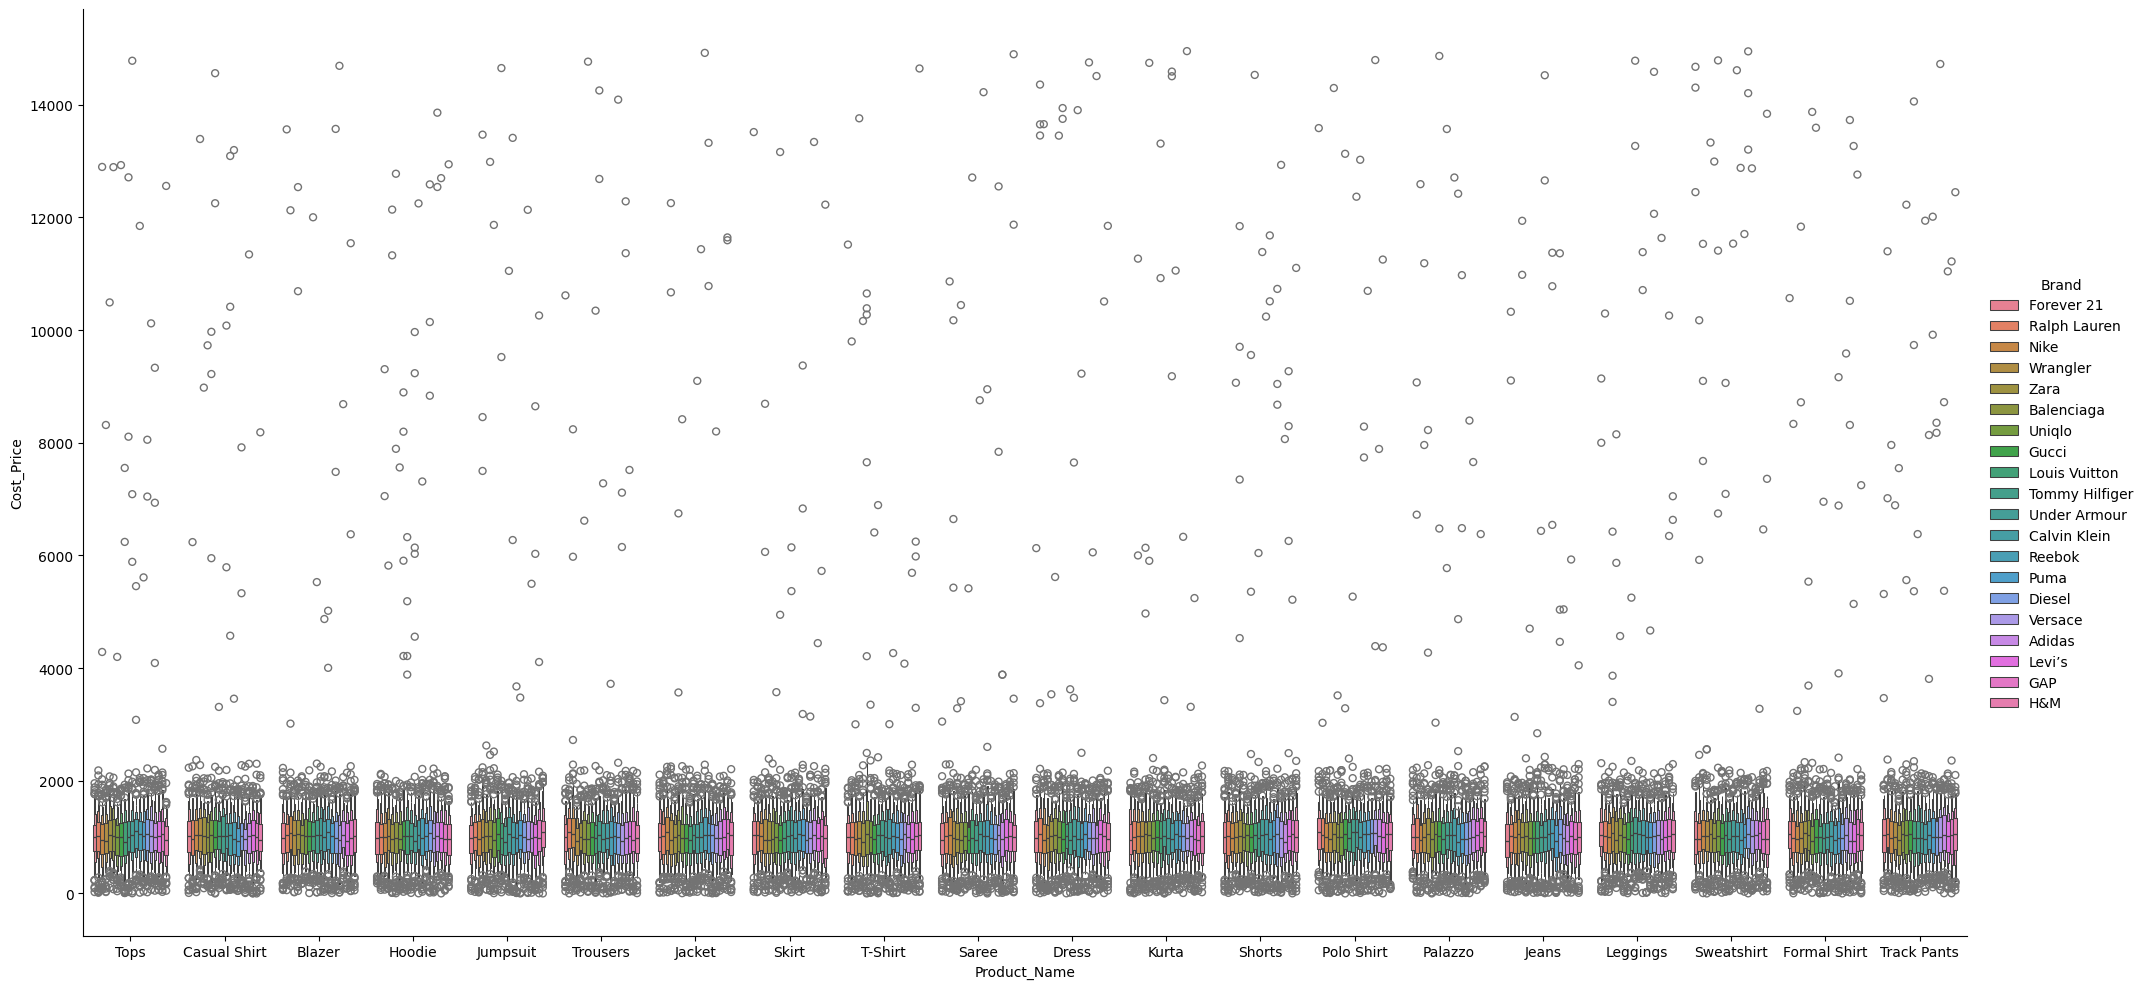

In [220]:
# plt.figure(figsize=(15,5))
ax=sns.catplot(data=dfclean, x='Product_Name', y='Cost_Price', hue='Brand', kind='boxen', height=10, aspect=2 )
ax.set_titles('Distribution of Cost Price')

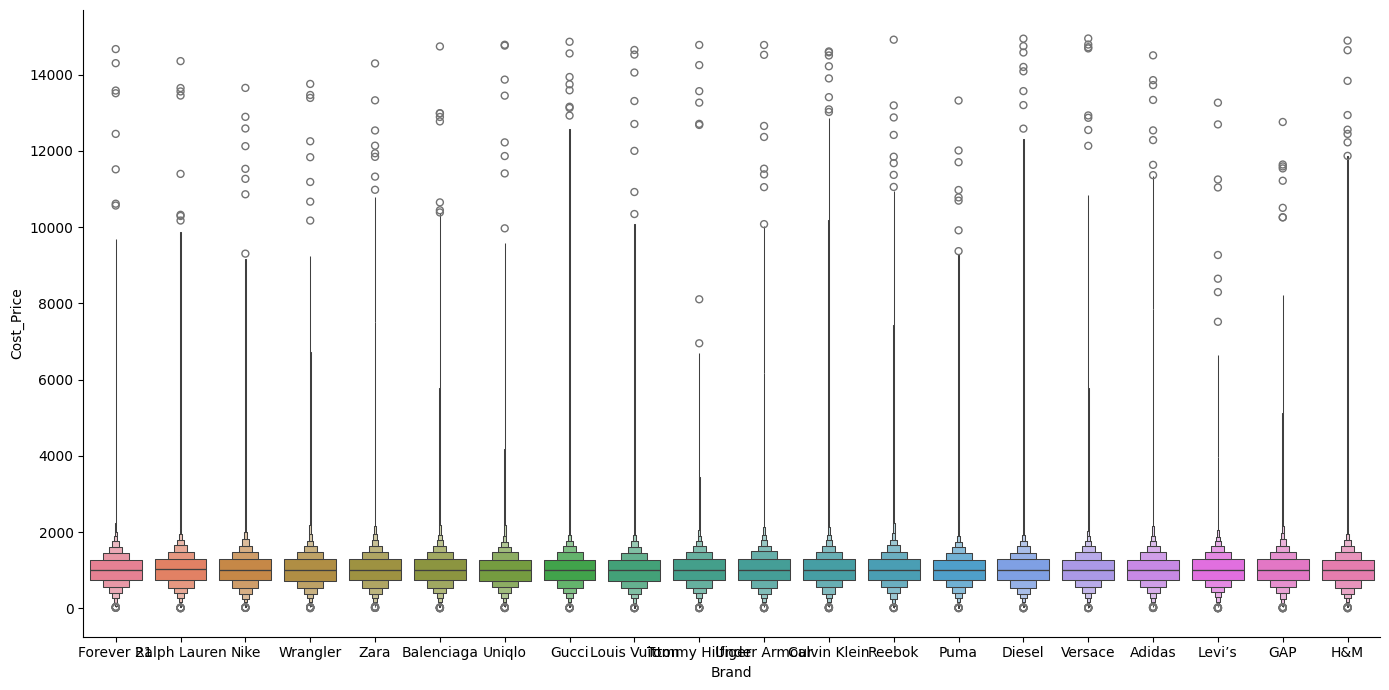

In [221]:
ax=sns.catplot(data=dfclean, x='Brand', y='Cost_Price', hue='Brand', kind='boxen', height=7, aspect=2 )
ax.set_titles('Distribution of Cost Price by Brand')

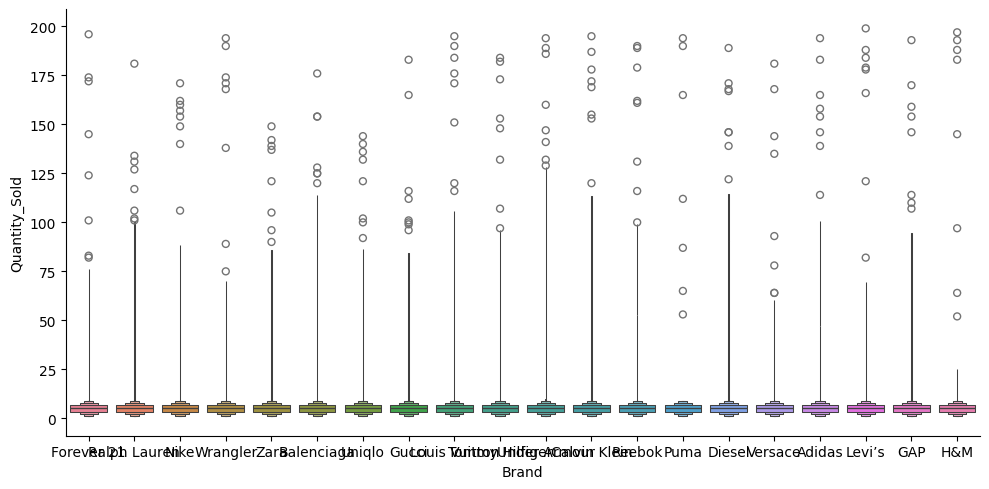

In [222]:
ax=sns.catplot(data=dfclean, x='Brand', y='Quantity_Sold', hue='Brand', kind='boxen', height=5, aspect=2 )
ax.set_titles('Distribution of Quantity Sold by Brand')

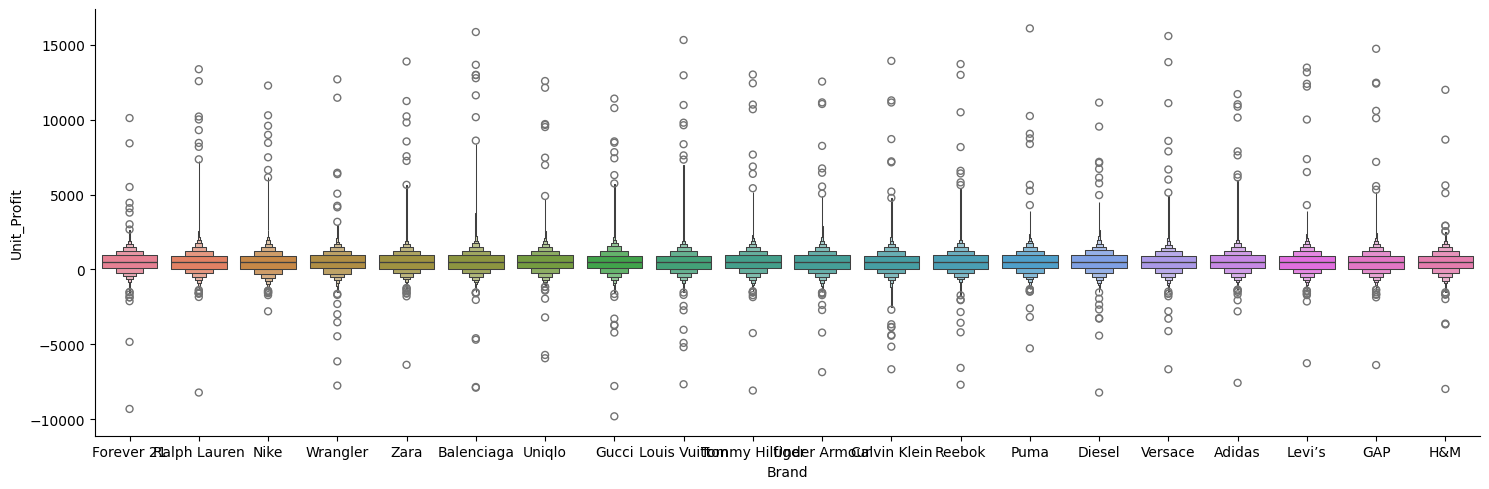

In [223]:
ax=sns.catplot(data=dfclean, x='Brand', y='Unit_Profit', hue='Brand', kind='boxen', height=5, aspect=3 )
ax.set_titles('Distribution of Unit_Profit by Brand')

In [224]:
# dfclean = dfclean[dfclean['Brand']=='Zara']

In [225]:
print(dfclean.shape)
dfclean.select_dtypes(include='number').columns

(77298, 19)


Index(['Selling_Price', 'Cost_Price', 'Discount_Percentage', 'Quantity_Sold',
       'Stock_Availability', 'Purchase_Frequency', 'Return_Rate', 'Total_Cost',
       'Total_Sales2', 'Unit_Profit', 'Unit_Margin', 'Profit', 'Margin'],
      dtype='object')

In [226]:
dfclean['Brand'].unique()

array(['Forever 21', 'Ralph Lauren', 'Nike', 'Wrangler', 'Zara',
       'Balenciaga', 'Uniqlo', 'Gucci', 'Louis Vuitton', 'Tommy Hilfiger',
       'Under Armour', 'Calvin Klein', 'Reebok', 'Puma', 'Diesel',
       'Versace', 'Adidas', 'Levi’s', 'GAP', 'H&M'], dtype=object)

<Axes: >

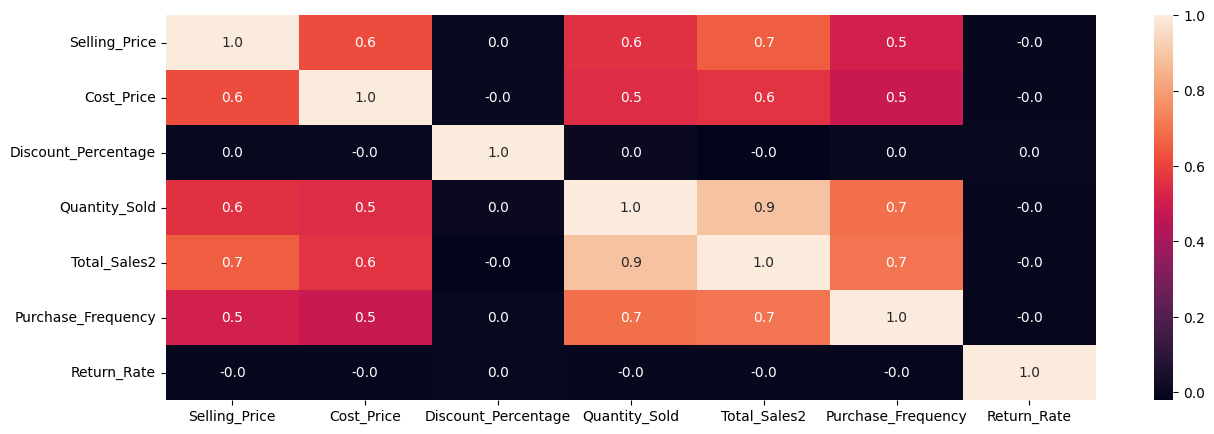

In [227]:
dftest =  dfclean[['Selling_Price', 'Cost_Price', 'Discount_Percentage', 'Quantity_Sold',
       'Total_Sales2', 'Purchase_Frequency', 'Return_Rate']]
plt.figure(figsize=(15,5))
sns.heatmap(dftest.corr(), annot=True, fmt='.1f')

In [228]:
dfclean[dfclean['Profit']<0].select_dtypes(include='number')

,Selling_Price,Cost_Price,Discount_Percentage,Quantity_Sold,Stock_Availability,Purchase_Frequency,Return_Rate,Total_Cost,Total_Sales2,Unit_Profit,Unit_Margin,Profit,Margin
6,1191.442375,1159.158217,31.015017,5,387.0,1.083173,6.338736,5.795791e+03,4.109582e+03,32.284158,0.027097,-1.686210e+03,-0.410312
7,296.437161,1656.010130,6.067290,6,56.0,2.992408,0.913214,9.936061e+03,1.670709e+03,-1359.572970,-4.586378,-8.265352e+03,-4.947213
8,1089.111866,977.451474,38.592452,2,56.0,2.832176,4.865411,1.954903e+03,1.337594e+03,111.660392,0.102524,-6.173092e+02,-0.461507
9,1546.977432,1331.422136,19.461967,2,92.0,2.622983,4.116767,2.662844e+03,2.491810e+03,215.555296,0.139340,-1.710339e+02,-0.068638
12,1352.939214,1480.667077,30.949482,4,219.0,3.803581,24.763827,5.922668e+03,3.736846e+03,-127.727862,-0.094408,-2.185822e+03,-0.584938
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99978,10011.554020,14254.405834,18.314264,173,148.0,37.000000,3.244253,2.466012e+06,1.414796e+06,-4242.851813,-0.423796,-1.051216e+06,-0.743016
99981,5330.454308,8316.087067,24.519030,190,472.0,34.000000,13.873954,1.580057e+06,7.644609e+05,-2985.632759,-0.560108,-8.155956e+05,-1.066890
99988,8678.599317,11386.209845,48.584398,129,134.0,33.000000,27.236810,1.468821e+06,5.756179e+05,-2707.610528,-0.311987,-8.932032e+05,-1.551729
99989,6214.092726,10670.507938,49.332854,138,309.0,41.000000,26.727464,1.472530e+06,4.344935e+05,-4456.415213,-0.717147,-1.038037e+06,-2.389073


# MANIPULATE DATA
remove extreme outliers in quantity sold or cost price \
but still keep some anomalies

## Remove Extreme Outlier in Cost Price

In [229]:
upperlimit = dfclean['Cost_Price'].quantile(0.99)
dfclean2 = dfclean.copy()
dfclean2['Cost_Price'] = dfclean2['Cost_Price'].clip(upper=upperlimit)

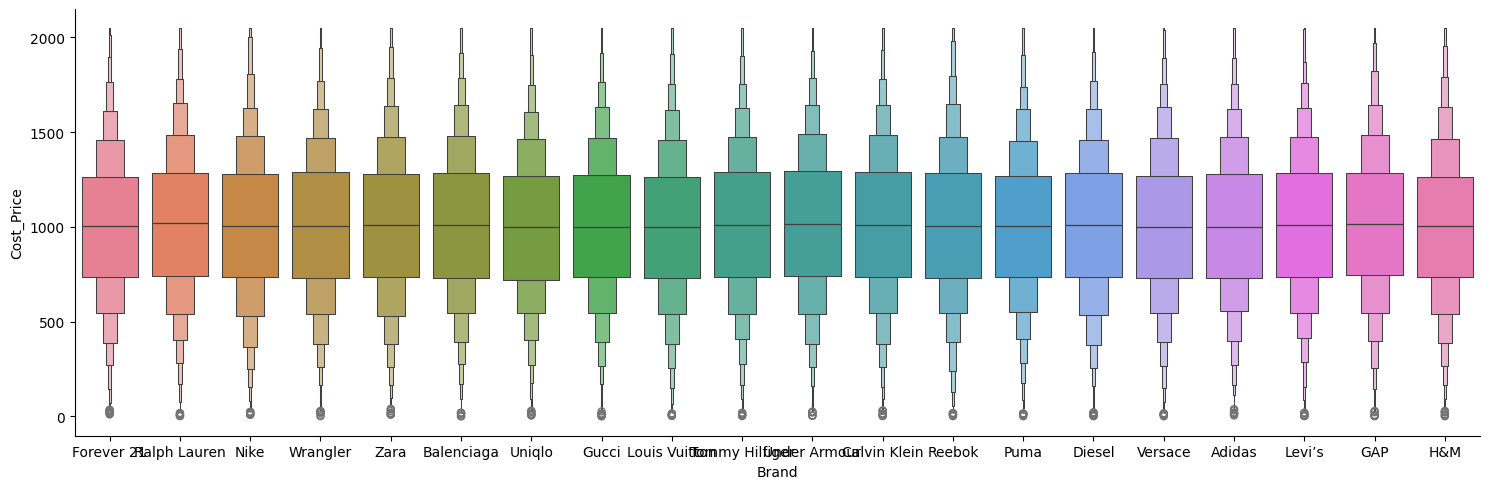

In [230]:
# rerun the distribution
g = sns.catplot(data=dfclean2, x='Brand', y='Cost_Price', hue='Brand', height=5, aspect=3, kind='boxen')
g.set_titles('NEW distribution of cost price per brand')

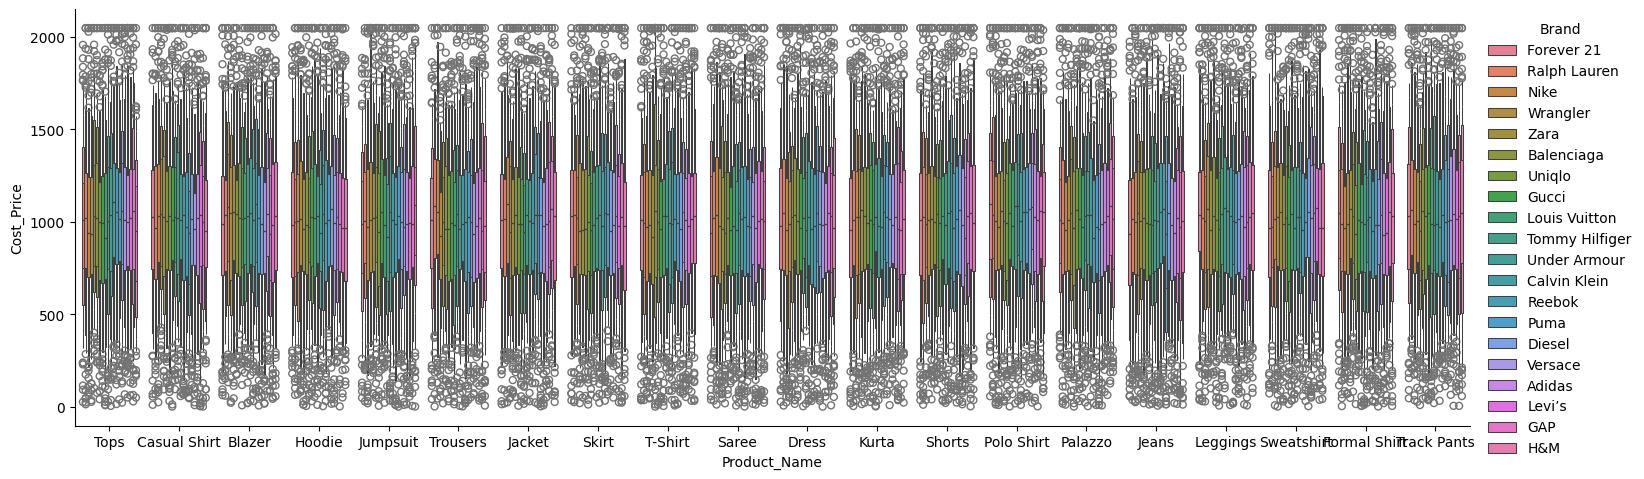

In [231]:
g = sns.catplot(data=dfclean2, x='Product_Name', y='Cost_Price', hue='Brand', height=5, aspect=3, kind='boxen')
g.set_titles('NEW distribution of cost price per product name')

## Remove Extreme Outlier in Quantity

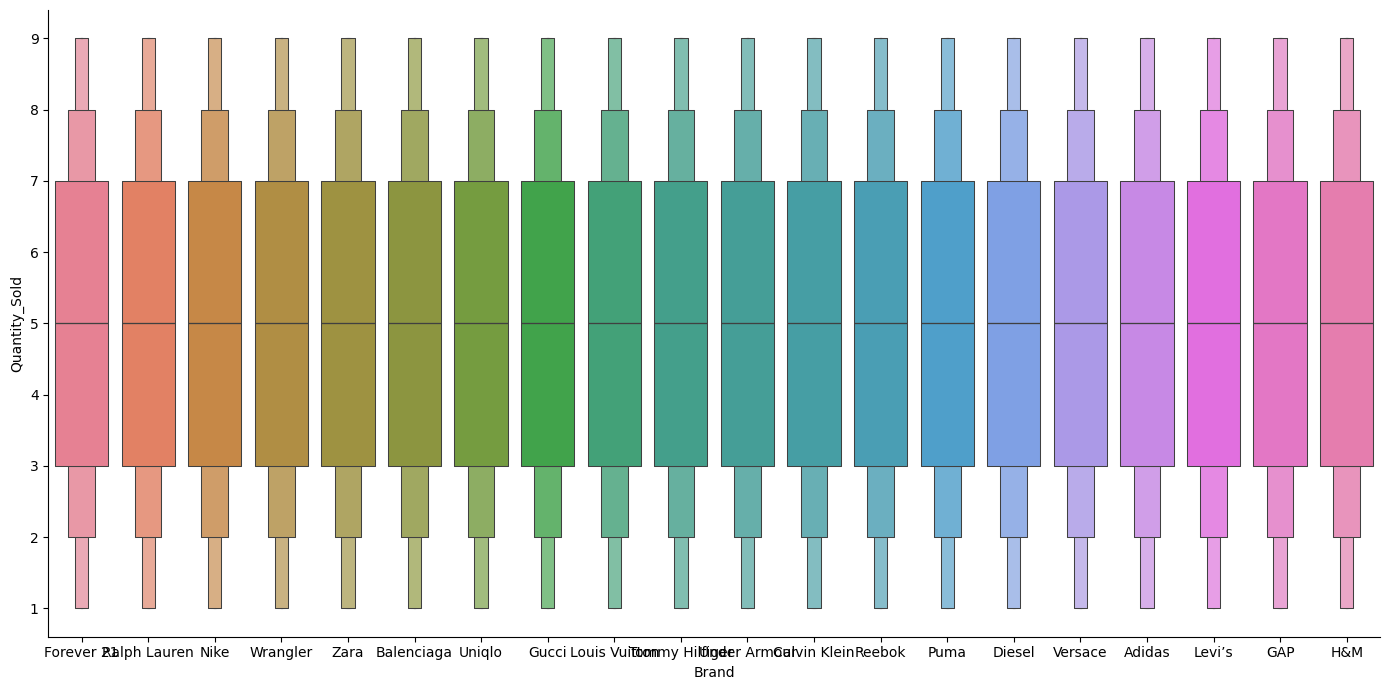

In [232]:
upperlimit_qty = dfclean2['Quantity_Sold'].quantile(0.99)
dfclean2['Quantity_Sold'] = dfclean2['Quantity_Sold'].clip(upper=upperlimit_qty)

ax=sns.catplot(data=dfclean2, x='Brand', y='Quantity_Sold', hue='Brand', kind='boxen', height=7, aspect=2 )
ax.set_titles('New Distribution of Quantity_Sold by Brand')

## Remove Extreme Outlier in Selling Price

In [233]:
lowerlimit_price = dfclean2['Selling_Price'].quantile(0.01)
upperlimit_price = dfclean2['Selling_Price'].quantile(0.99)
dfclean3 = dfclean2.copy(deep=True)
dfclean3['Selling_Price'] = dfclean3['Selling_Price'].clip(lower=lowerlimit_price, upper=upperlimit_price)
print(dfclean3.shape)
dfclean3

(77298, 19)


,Brand,Product_Name,Gender,Size,Color,Season,Selling_Price,Cost_Price,Discount_Percentage,Quantity_Sold,Stock_Availability,Purchase_Frequency,Return_Rate,Total_Cost,Total_Sales2,Unit_Profit,Unit_Margin,Profit,Margin
0,Forever 21,Tops,Women,S,White,Winter,1817.433878,816.027585,26.260791,6,294.0,2.560957,29.293331,4.896166e+03,8.040968e+03,1001.406292,0.551000,3.144803e+03,0.391098
1,Ralph Lauren,Casual Shirt,Men,XXL,Yellow,All-Season,1672.038198,793.236861,26.882613,8,376.0,1.590993,19.473670,6.345895e+03,9.780405e+03,878.801337,0.525587,3.434510e+03,0.351162
2,Nike,Blazer,Men,S,Green,All-Season,1381.568069,890.469629,30.274720,5,48.0,3.066213,22.083407,4.452348e+03,4.816511e+03,491.098440,0.355465,3.641629e+02,0.075607
6,Wrangler,Hoodie,Men,M,White,All-Season,1191.442375,1159.158217,31.015017,5,387.0,1.083173,6.338736,5.795791e+03,4.109582e+03,32.284158,0.027097,-1.686210e+03,-0.410312
7,Zara,Jumpsuit,Women,XL,Orange,Winter,337.151696,1656.010130,6.067290,6,56.0,2.992408,0.913214,9.936061e+03,1.670709e+03,-1359.572970,-4.586378,-8.265352e+03,-4.947213
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99992,Gucci,Saree,Women,S,Blue,Summer,2796.933419,2046.966553,10.186200,9,353.0,33.000000,17.060001,5.361869e+05,1.241291e+06,8544.292015,0.612041,7.051043e+05,0.568041
99996,Zara,Shorts,Women,L,Blue,All-Season,2796.933419,2046.966553,11.782079,9,390.0,36.000000,22.948494,1.018900e+06,1.806839e+06,9802.416466,0.502528,7.879386e+05,0.436087
99997,Calvin Klein,Jacket,Women,XL,Orange,Winter,2796.933419,2046.966553,25.184848,9,435.0,23.000000,15.803273,1.967094e+06,1.174933e+06,-2306.078649,-0.252568,-7.921606e+05,-0.674217
99998,Nike,Sweatshirt,Women,S,White,Winter,2796.933419,2046.966553,2.788690,9,452.0,46.000000,1.867981,1.775907e+06,2.846554e+06,7482.500604,0.393518,1.070646e+06,0.376120


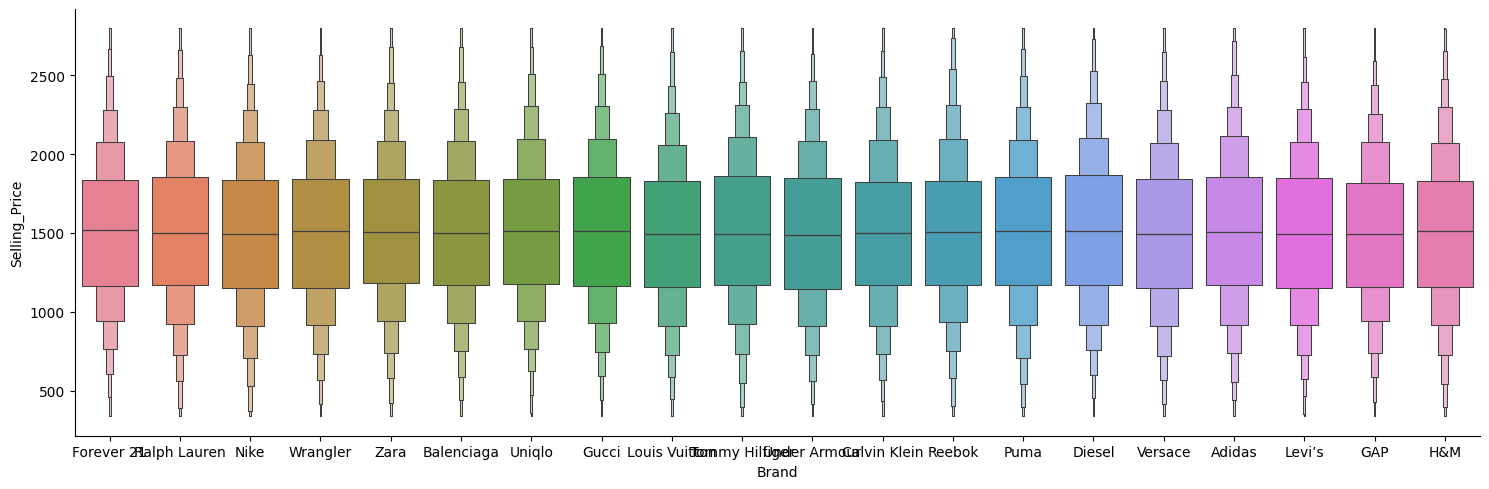

In [234]:
g=sns.catplot(kind='boxen', data=dfclean3, x='Brand', y='Selling_Price', hue='Brand', height=5, aspect=3)
g.set_titles('NEW Distribution of Selling price per brand')

# Column list

In [17]:
df.columns

Index(['Product_Category', 'Brand', 'Product_Name', 'Gender', 'Size', 'Color',
       'Season', 'Payment_Method', 'Customer_Type', 'Selling_Price',
       'Cost_Price', 'Discount_Percentage', 'Quantity_Sold', 'Total_Sales',
       'Stock_Availability', 'Customer_Age', 'Purchase_Frequency',
       'Store_Rating', 'Return_Rate', 'Sales_Category'],
      dtype='object')

# Plot

In [78]:
def plot_y_by_x(df, col_list, y_col, estimator='sum'):
    n_plots = len(col_list)
    n_cols = 3
    n_rows = math.ceil(n_plots/n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize = (15, 4*n_rows))
    axes = axes.flatten()

    for i, col in enumerate(col_list):
        # summary y by each x
        sns.barplot(ax=axes[i], data=df, x=col, y=y_col, errorbar=None, estimator=estimator)
        axes[i].set_title(f'avg {y_col} by {col}')
        axes[i].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show

In [19]:
dfclean.select_dtypes(include='object').columns

Index(['Product_Category', 'Brand', 'Product_Name', 'Gender', 'Size', 'Color',
       'Season', 'Payment_Method', 'Customer_Type', 'Sales_Category'],
      dtype='object')

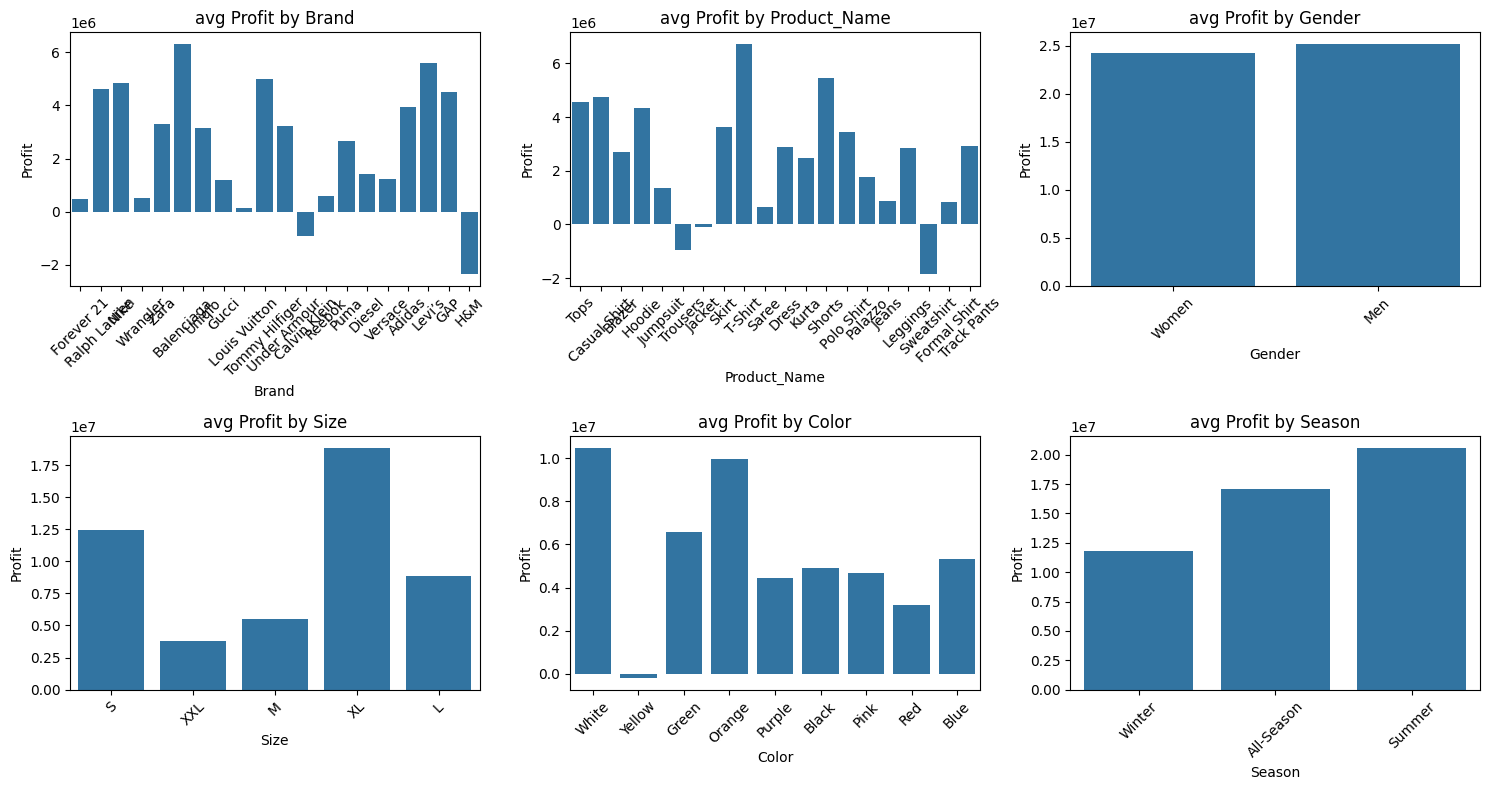

In [235]:
col_list = [ 'Brand', 'Product_Name', 'Gender', 'Size', 'Color', 'Season']
y_col = 'Profit'
plot_y_by_x(dfclean3, col_list, y_col)

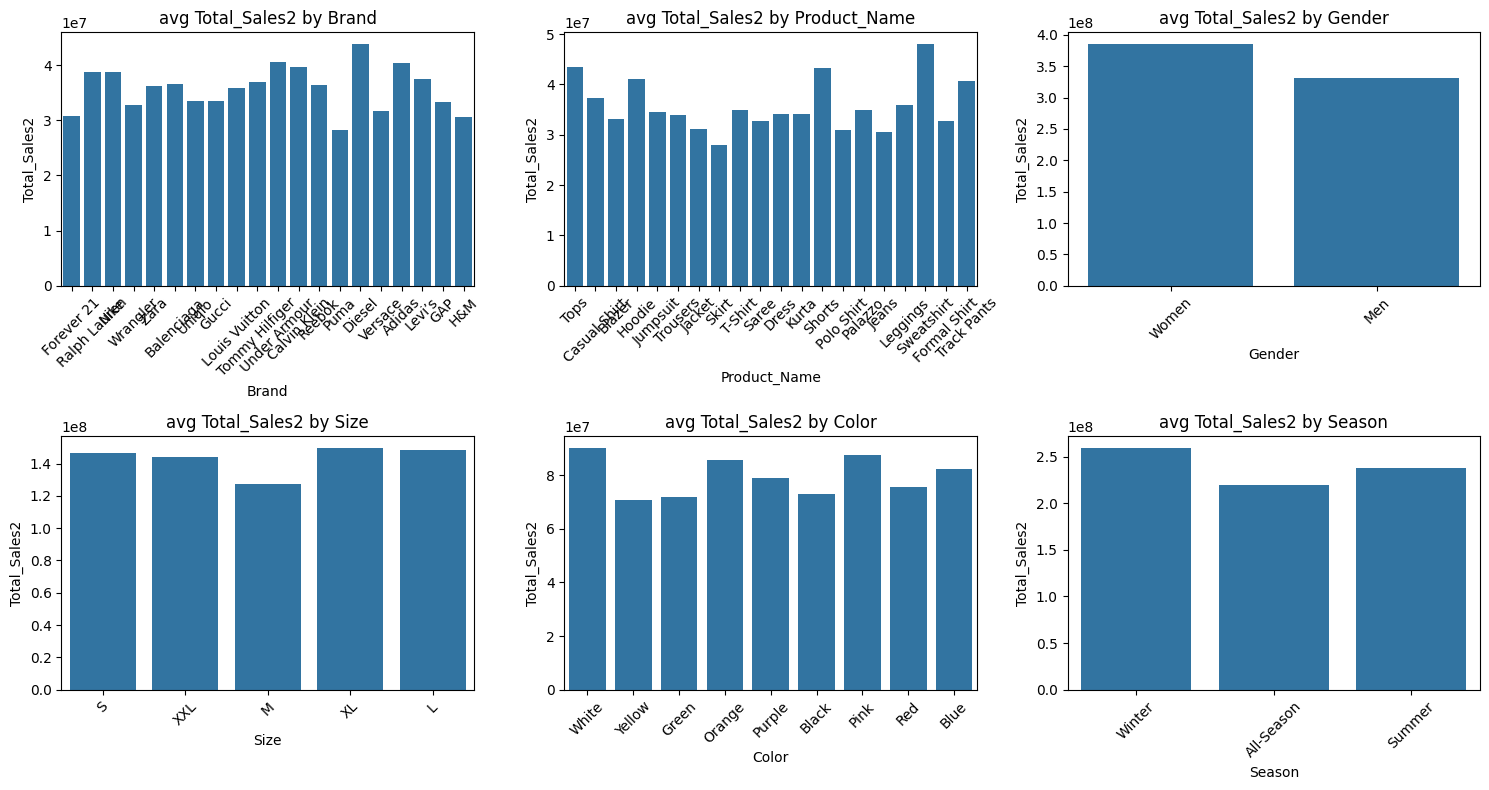

In [236]:
y_col = 'Total_Sales2'
plot_y_by_x(dfclean3, col_list, y_col)

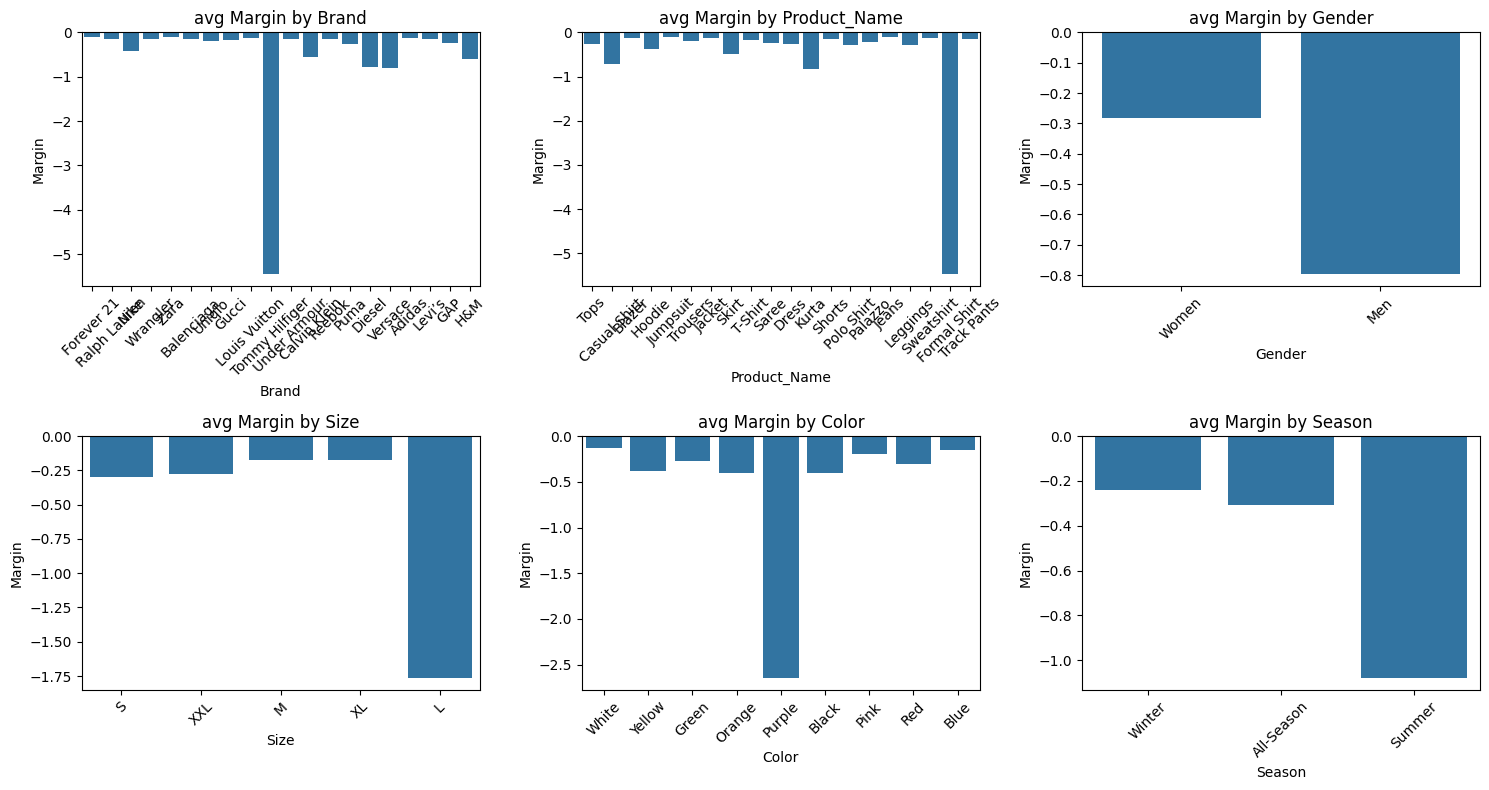

In [237]:
y_col = 'Margin'
plot_y_by_x(dfclean3, col_list, y_col, 'mean')

# Outlier

In [85]:
def display_outlier(df, x_list):
    n_cols = 3
    n_rows = math.ceil(len(x_list) / 3)

    fig, axes = plt.subplots(ncols=n_cols, nrows=n_rows, figsize= (15, 3*n_rows))
    axes = axes.flatten()
    for i, col in enumerate(x_list):
        sns.boxenplot(data=df, x=col, ax=axes[i])
        axes[i].set_title(f'{col}')
    
    plt.tight_layout()
    plt.show()

In [32]:
dfclean.select_dtypes(include='number').columns

Index(['Selling_Price', 'Cost_Price', 'Discount_Percentage', 'Quantity_Sold',
       'Total_Sales', 'Stock_Availability', 'Customer_Age',
       'Purchase_Frequency', 'Store_Rating', 'Return_Rate', 'Total_Sales2',
       'Unit_Profit', 'Unit_Margin', 'Profit', 'Margin'],
      dtype='object')

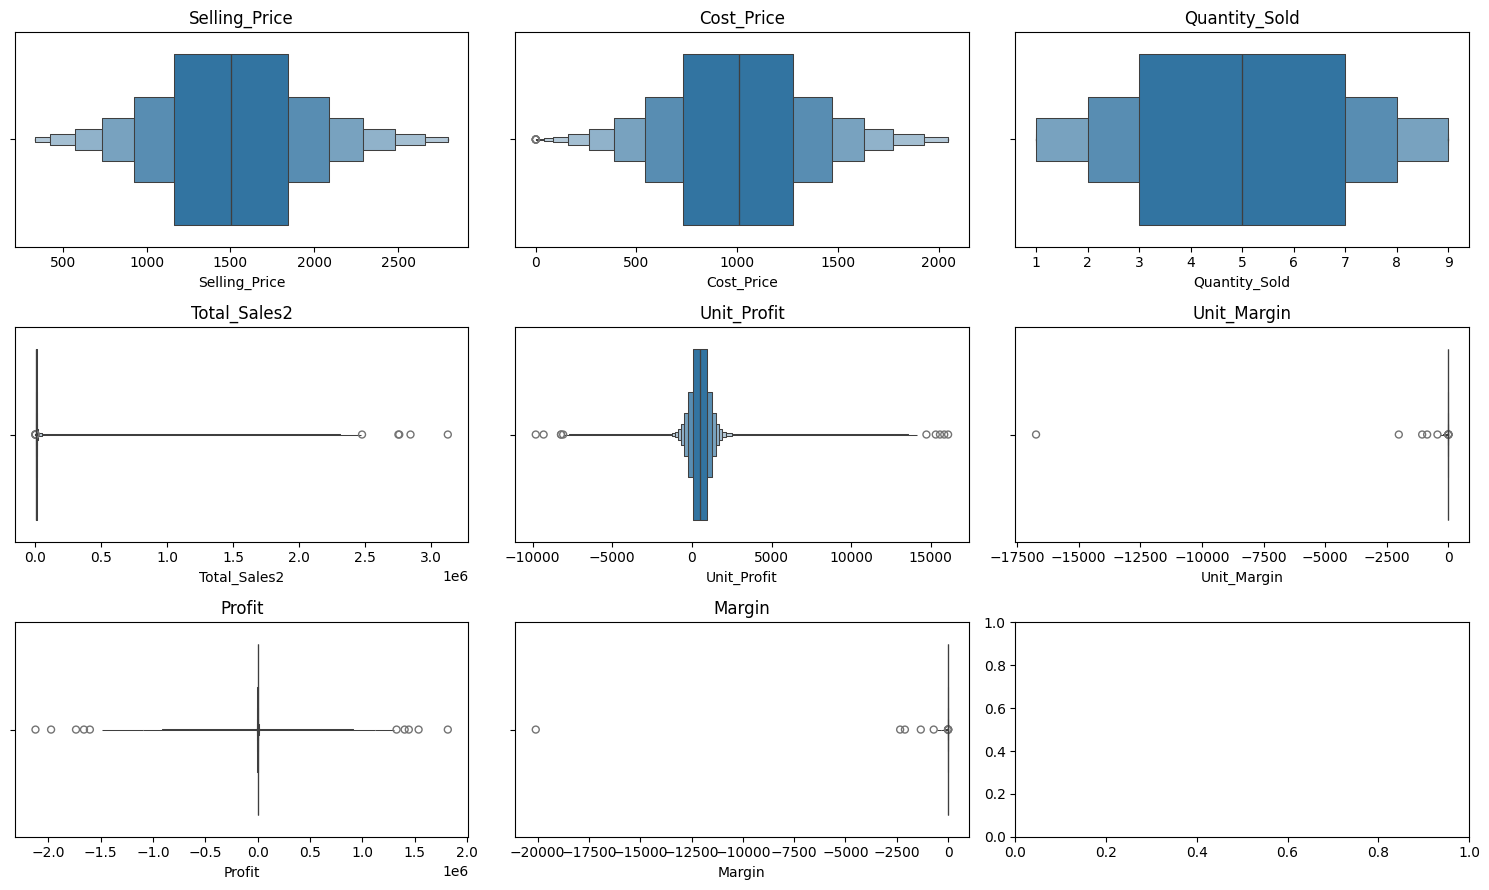

In [238]:
x_list = dfclean3.select_dtypes(include='number').columns
x_list = ['Selling_Price', 'Cost_Price', 'Quantity_Sold',
        'Total_Sales2',  'Unit_Profit', 'Unit_Margin', 'Profit', 'Margin']
display_outlier(dfclean3, x_list)


In [243]:
dfclean3[dfclean3['Unit_Margin']<0].sort_values('Unit_Margin').eval('Unit_Margin = 1 - Cost_Price / Selling_Price')

,Brand,Product_Name,Gender,Size,Color,Season,Selling_Price,Cost_Price,Discount_Percentage,Quantity_Sold,Stock_Availability,Purchase_Frequency,Return_Rate,Total_Cost,Total_Sales2,Unit_Profit,Unit_Margin,Profit,Margin
69035,Tommy Hilfiger,Formal Shirt,Men,L,Purple,Summer,337.151696,1211.007316,16.727761,6,184.0,1.727870,15.346703,7266.043896,0.361626,-1210.934938,-2.591877,-7265.682271,-20091.722936
17966,Diesel,Casual Shirt,Women,L,Black,Summer,337.151696,1188.088631,13.916668,3,174.0,3.648457,23.966988,3564.265894,1.525053,-1187.498098,-2.523899,-3562.740841,-2336.142374
70568,Versace,Kurta,Men,S,Orange,All-Season,337.151696,871.389287,49.428659,5,32.0,3.062122,9.795330,4356.946434,2.070334,-870.570509,-1.584561,-4354.876100,-2103.465281
1607,Calvin Klein,Skirt,Women,L,Yellow,Winter,337.151696,1142.484650,35.238207,6,76.0,0.590524,28.080244,6854.907899,5.151214,-1141.158968,-2.388637,-6849.756685,-1329.736457
97785,H&M,Hoodie,Men,XXL,Purple,Winter,337.151696,1296.183982,36.725926,5,179.0,1.922377,8.010457,6480.919912,9.244450,-1293.261948,-2.844513,-6471.675462,-700.060602
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1716,Zara,Trousers,Women,XL,Red,Summer,836.587269,836.633929,15.891982,5,445.0,1.506627,27.891893,4183.169647,3518.184846,-0.046661,-0.000056,-664.984801,-0.189014
11241,Adidas,Casual Shirt,Men,L,Green,Winter,679.521706,679.557084,13.083527,6,275.0,2.941157,3.932350,4077.342503,3543.697789,-0.035378,-0.000052,-533.644714,-0.150590
53966,Diesel,Track Pants,Women,M,White,All-Season,1762.903164,1762.974175,15.472793,5,469.0,1.384094,15.252399,8814.870874,7450.664024,-0.071010,-0.000040,-1364.206850,-0.183099
52204,Balenciaga,Shorts,Men,M,Red,Summer,2104.084577,2046.966553,19.559845,2,269.0,0.700117,26.000498,4208.303564,3385.057805,-0.067204,0.027146,-823.245758,-0.243200


In [27]:
dfclean[dfclean['Margin']>0]

,Product_Category,Brand,Product_Name,Gender,Size,Color,Season,Payment_Method,Customer_Type,Selling_Price,...,Purchase_Frequency,Store_Rating,Return_Rate,Sales_Category,Total_Cost,Total_Sales2,Unit_Profit,Unit_Margin,Profit,Margin
0,Traditional Wear,Forever 21,Tops,Women,S,White,Winter,Card,New,1817.433878,...,2.560957,3.106155,29.293331,High Sales,4.896166e+03,8.040968e+03,1001.406292,0.551000,3.144803e+03,0.391098
1,Athleisure,Ralph Lauren,Casual Shirt,Men,XXL,Yellow,All-Season,Card,Returning,1672.038198,...,1.590993,3.428439,19.473670,Low Sales,6.345895e+03,9.780405e+03,878.801337,0.525587,3.434510e+03,0.351162
2,Outerwear,Nike,Blazer,Men,S,Green,All-Season,UPI,Returning,1381.568069,...,3.066213,3.765591,22.083407,Medium Sales,4.452348e+03,4.816511e+03,491.098440,0.355465,3.641629e+02,0.075607
10,Traditional Wear,Ralph Lauren,Jacket,Men,M,Black,All-Season,Cash,New,587.297333,...,1.151096,4.126842,16.171187,Medium Sales,1.412215e+03,2.151669e+03,351.928228,0.599233,7.394541e+02,0.343665
13,Bottoms,Louis Vuitton,T-Shirt,Women,XL,Purple,Winter,Card,Returning,1784.431124,...,2.530368,4.045500,22.149408,High Sales,9.030719e+02,3.059784e+03,1483.407174,0.831305,2.156712e+03,0.704858
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99991,Bottoms,Tommy Hilfiger,Formal Shirt,Women,S,Black,All-Season,Card,New,14618.593595,...,33.000000,1.546889,11.997911,High Sales,1.063914e+06,1.732542e+06,7664.910326,0.524326,6.686281e+05,0.385923
99992,Bottoms,Gucci,Saree,Women,S,Blue,Summer,Card,Returning,13960.321511,...,33.000000,2.060260,17.060001,Low Sales,5.361869e+05,1.241291e+06,8544.292015,0.612041,7.051043e+05,0.568041
99996,Tops,Zara,Shorts,Women,L,Blue,All-Season,Net Banking,New,19506.226429,...,36.000000,1.654000,22.948494,Medium Sales,1.018900e+06,1.806839e+06,9802.416466,0.502528,7.879386e+05,0.436087
99998,Traditional Wear,Nike,Sweatshirt,Women,S,White,Winter,Cash,New,19014.366546,...,46.000000,2.141555,1.867981,High Sales,1.775907e+06,2.846554e+06,7482.500604,0.393518,1.070646e+06,0.376120


In [39]:
dfclean.select_dtypes(include='number').columns

Index(['Selling_Price', 'Cost_Price', 'Discount_Percentage', 'Quantity_Sold',
       'Total_Sales', 'Stock_Availability', 'Customer_Age',
       'Purchase_Frequency', 'Store_Rating', 'Return_Rate', 'Total_Sales2',
       'Unit_Profit', 'Unit_Margin', 'Profit', 'Margin'],
      dtype='object')

# Profit Margin In General

In [215]:
totalsales = dfclean['Total_Sales2'].sum()
totalcost = dfclean['Total_Cost'].sum()
profit = totalsales - totalcost
margin = profit / totalsales * 100
print(f'Total sales: {totalsales} \n Total cost: {totalcost} \n profit: {profit} \n margin: {margin} ')

Total sales: 25956386.62715235 
 Total cost: 23825176.93307557 
 profit: 2131209.69407678 
 margin: 8.210733353183194 


# Profitable Product Category

In [218]:
def groupby_attribute(df, groupcolname):
    df2=df.pivot_table(index=groupcolname, values = ['Total_Sales2', 'Total_Cost', 'Profit'], aggfunc='sum').reset_index()
    df2[f'Margin{groupcolname}'] = df2['Profit'] / df2['Total_Sales2'] * 100
    
    return df2.sort_values(by=f'Margin{groupcolname}', ascending=False)

In [89]:
dfclean.select_dtypes(include='object').columns

Index(['Product_Category', 'Brand', 'Product_Name', 'Gender', 'Size', 'Color',
       'Season', 'Payment_Method', 'Customer_Type', 'Sales_Category'],
      dtype='object')

In [ ]:
# Product Category not match with Product Name so to remove category column
dfproductcat = dfclean.pivot_table(index='Product_Category', values = ['Total_Sales2', 'Total_Cost', 'Profit'], aggfunc='sum' ).reset_index()
dfproductcat['Margin2'] = dfproductcat['Profit'] / dfproductcat['Total_Sales2'] * 100
dfproductcat.sort_values(by='Margin2',ascending=False)

,Product_Category,Profit,Total_Cost,Total_Sales2,Margin2
4,Traditional Wear,1.735063e+06,5.834013e+06,7.569076e+06,22.923050
0,Athleisure,4.275167e+05,4.906156e+06,5.333673e+06,8.015428
1,Bottoms,5.337735e+05,6.766091e+06,7.299864e+06,7.312101
2,Outerwear,5.649855e+05,7.237682e+06,7.802667e+06,7.240927
3,Tops,-1.062204e+05,5.578774e+06,5.472554e+06,-1.940967


# Profitable Product

In [219]:
dfproduct = groupby_attribute(dfclean, 'Product_Name')
dfproduct

,Product_Name,Profit,Total_Cost,Total_Sales2,MarginProduct_Name
16,T-Shirt,1.277860e+06,1.186665e+06,2.464525e+06,51.850160
15,Sweatshirt,7.625142e+05,2.816961e+06,3.579475e+06,21.302401
14,Skirt,1.645768e+05,6.785645e+05,8.431413e+05,19.519483
13,Shorts,1.164667e+05,6.582469e+05,7.747136e+05,15.033519
17,Tops,1.251215e+05,7.233252e+05,8.484467e+05,14.747122
11,Polo Shirt,1.207128e+05,7.850167e+05,9.057295e+05,13.327687
4,Hoodie,1.043618e+05,7.176640e+05,8.220257e+05,12.695681
1,Casual Shirt,9.301181e+04,7.050543e+05,7.980661e+05,11.654650
9,Leggings,8.756336e+04,7.635529e+05,8.511163e+05,10.288061
8,Kurta,7.351383e+04,6.802397e+05,7.537535e+05,9.753033


Text(0.5, 1.0, 'Margin by Product')

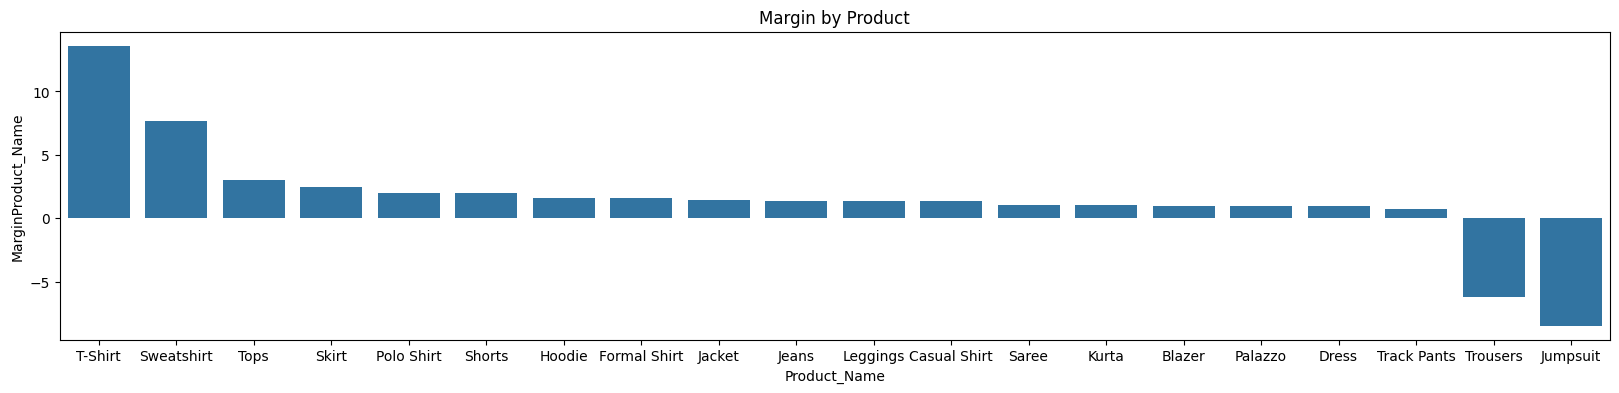

In [92]:
plt.figure(figsize=(20, 4))
ax = sns.barplot(data=dfproduct, x='Product_Name', y='MarginProduct_Name')
ax.set_title('Margin by Product')

Text(0.5, 1.0, 'Best selling products')

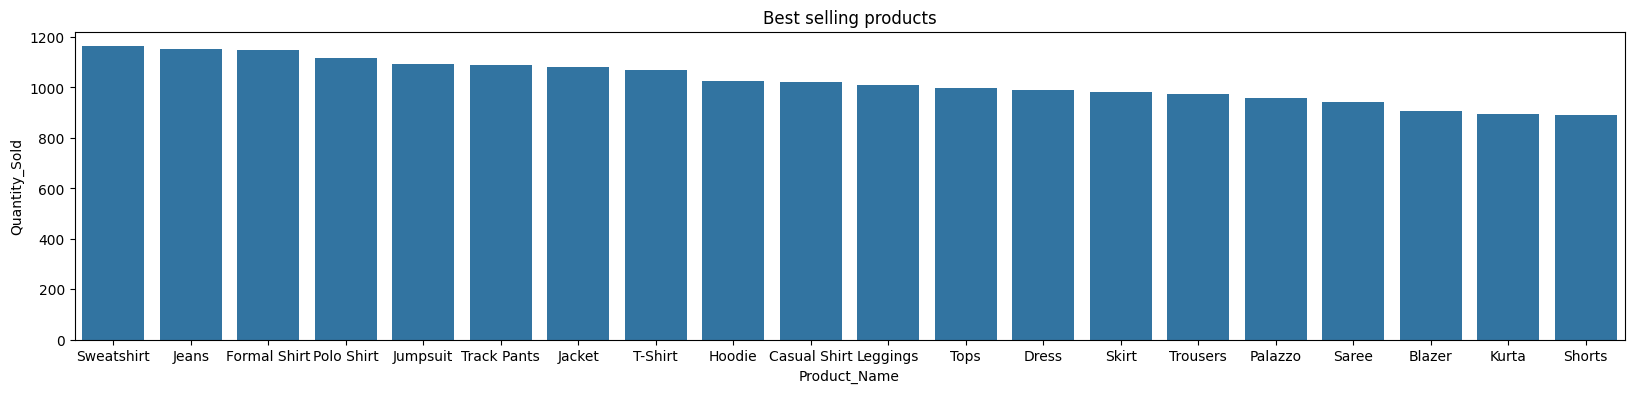

In [93]:
# By Volumn
dfproduct_qty = dfclean.pivot_table(index='Product_Name', values='Quantity_Sold', aggfunc='sum').reset_index().sort_values('Quantity_Sold', ascending=False)
plt.figure(figsize=(20,4))
ax= sns.barplot(data=dfproduct_qty, x='Product_Name', y='Quantity_Sold')
ax.set_title('Best selling products')

# WHY Uniqlo Jumpsuit Bottom Margin

In [220]:
dfjumpsuit = dfclean[dfclean['Product_Name']=='Jumpsuit']

print(dfjumpsuit.shape)
dfjumpsuit.head()

(139, 20)


,Brand,Product_Name,Gender,Size,Color,Season,Selling_Price,Cost_Price,Unit_Profit,Unit_Margin,Discount_Percentage,Quantity_Sold,Total_Sales2,Total_Cost,Profit,Margin,Stock_Availability,Purchase_Frequency,Store_Rating,Return_Rate
554,Uniqlo,Jumpsuit,Men,M,Red,Winter,730.510854,947.195085,-216.684231,-0.296620,30.992702,8,4032.846407,7577.560681,-3544.714274,-0.878961,320.0,2.297425,4.662328,7.675874
2258,Uniqlo,Jumpsuit,Men,L,Green,Winter,963.061123,653.905363,309.155760,0.321014,2.189119,2,1883.957135,1307.810726,576.146409,0.305817,360.0,0.982576,4.836955,22.538473
2698,Uniqlo,Jumpsuit,Women,XXL,Orange,All-Season,1784.849623,457.291775,1327.557847,0.743793,38.447614,8,8788.940271,3658.334201,5130.606070,0.583757,477.0,1.790062,3.999342,16.391260
2706,Uniqlo,Jumpsuit,Women,L,Green,All-Season,1733.255375,907.581114,825.674262,0.476372,42.007029,4,4020.665137,3630.324455,390.340682,0.097084,414.0,4.045926,3.123513,12.911368
4010,Uniqlo,Jumpsuit,Men,S,Orange,Summer,1628.742593,731.852244,896.890349,0.550664,30.365818,8,9073.292607,5854.817952,3218.474654,0.354720,323.0,1.963553,4.781370,23.150711


## Is it Cost driven?

In [314]:
# check average cost of other products
dfclean.pivot_table(index=['Product_Name'], values='Cost_Price', aggfunc=['mean', 'min', 'max', 'std']).reset_index()

,Product_Name,mean,min,max,std
,,Cost_Price,Cost_Price,Cost_Price,Cost_Price
0,Blazer,1044.926975,226.327828,1980.459707,415.444209
1,Casual Shirt,998.915072,30.373437,1872.516811,388.745118
2,Dress,1088.814364,50.628091,13452.678268,1104.435708
3,Formal Shirt,1067.889590,13.869796,13873.486998,1149.719150
4,Hoodie,1005.112085,59.306998,1952.327200,366.241190
5,Jacket,1057.253480,4.948885,8418.012588,759.243784
6,Jeans,1018.521684,61.408347,4700.992562,510.850381
7,Jumpsuit,1027.137534,5.080499,11867.523446,1023.685690
8,Kurta,1030.967523,179.489780,2194.900364,387.185933


In [315]:
dfclean.pivot_table(index=['Product_Name','Season', 'Gender'], values='Cost_Price', aggfunc=['mean', 'min', 'max', 'std']).reset_index()

,Product_Name,Season,Gender,mean,min,max,std
,,,,Cost_Price,Cost_Price,Cost_Price,Cost_Price
0,Blazer,All-Season,Men,845.138384,271.660564,1476.859027,347.205664
1,Blazer,All-Season,Women,1181.957812,708.155114,1737.473391,328.854237
2,Blazer,Summer,Men,1029.211553,434.332637,1928.871955,416.879431
3,Blazer,Summer,Women,1011.402336,226.327828,1686.838952,449.379065
4,Blazer,Winter,Men,1126.070469,389.450396,1896.317079,471.957199
...,...,...,...,...,...,...,...
115,Trousers,All-Season,Women,916.794874,29.671323,1633.624198,370.467198
116,Trousers,Summer,Men,935.839014,125.830655,1571.922924,403.910600
117,Trousers,Summer,Women,899.597860,288.835787,1481.509953,309.815824


## Is its discount too high?

In [222]:
dfclean.pivot_table(index=['Product_Name'], values='Discount_Percentage', aggfunc=['mean','min', 'max']).reset_index()

,Product_Name,mean,min,max
,,Discount_Percentage,Discount_Percentage,Discount_Percentage
0,Blazer,24.165259,0.125757,49.755931
1,Casual Shirt,26.050947,0.691598,49.701229
2,Dress,27.178827,0.028467,49.458260
3,Formal Shirt,24.682047,0.181339,49.695614
4,Hoodie,23.698989,0.154813,49.927751
5,Jacket,24.377019,0.081207,49.821312
6,Jeans,27.346172,0.376765,49.685619
7,Jumpsuit,26.111417,0.180631,49.313840
8,Kurta,25.277756,0.397393,49.977944


## Is this product highest return rate?
They seem no abnormal rate

In [223]:
dfclean.pivot_table(index=['Product_Name'], values='Return_Rate', aggfunc=['mean','min', 'max']).reset_index()

,Product_Name,mean,min,max
,,Return_Rate,Return_Rate,Return_Rate
0,Blazer,15.052019,0.024133,29.680910
1,Casual Shirt,14.892630,0.019804,29.903951
2,Dress,16.478539,0.230750,29.869777
3,Formal Shirt,15.293667,0.224131,29.770383
4,Hoodie,14.417858,0.025476,29.546958
5,Jacket,14.754190,0.696167,29.749382
6,Jeans,15.864594,0.172903,29.932520
7,Jumpsuit,15.080681,0.159216,29.823830
8,Kurta,15.677566,0.247751,29.658376


## Which product elements

### Worst color

In [224]:
## Which product attributes having negative profits?
dfjumpsuit.pivot_table(index='Color', values='Profit', aggfunc=['mean', 'min','max']).reset_index()

,Color,mean,min,max
,,Profit,Profit,Profit
0,Black,935.937040,-2403.493785,7256.908900
1,Blue,-60344.411778,-916447.132818,7845.675539
2,Green,-275.797038,-7371.414742,5479.653361
3,Orange,783.548060,-2994.176015,5130.606070
4,Pink,1842.916450,-2977.341454,7750.967717
5,Purple,1827.491126,-4751.547603,9682.141130
6,Red,1183.517007,-3544.714274,7317.297041
7,White,1561.867947,-3267.055721,7678.629958
8,Yellow,-879.079154,-8542.145715,3921.483173


In [126]:
dfjumpsuit.columns

Index(['Product_Category', 'Brand', 'Product_Name', 'Gender', 'Size', 'Color',
       'Season', 'Payment_Method', 'Customer_Type', 'Selling_Price',
       'Cost_Price', 'Discount_Percentage', 'Quantity_Sold', 'Total_Sales',
       'Stock_Availability', 'Customer_Age', 'Purchase_Frequency',
       'Store_Rating', 'Return_Rate', 'Sales_Category', 'Total_Cost',
       'Total_Sales2', 'Unit_Profit', 'Unit_Margin', 'Profit', 'Margin'],
      dtype='object')

### Worst size

In [225]:
dfjumpsuit.pivot_table(index='Size', values='Profit', aggfunc=['mean', 'min','max']).reset_index()

,Size,mean,min,max
,,Profit,Profit,Profit
0,L,-31908.130554,-916447.132818,6327.626277
1,M,551.664689,-8542.145715,7845.675539
2,S,1386.812752,-2301.363848,7317.297041
3,XL,1334.904528,-4047.730907,9682.141130
4,XXL,404.399461,-8089.532946,7750.967717


### Color x Size Profit

In [226]:
dfjumpsuit.groupby(['Color', 'Size'])['Profit'].agg(
    mean_val='mean',
    min_val='min',
    max_val='max'
).reset_index().sort_values('mean_val')

,Color,Size,mean_val,min_val,max_val
5,Blue,L,-229012.296589,-916447.132818,475.389831
44,Yellow,XXL,-3862.574243,-8089.532946,-154.749297
13,Green,XL,-2570.584246,-4047.730907,-1093.437585
27,Purple,S,-1714.614368,-1714.614368,-1714.614368
41,Yellow,M,-1525.173813,-8542.145715,1440.054418
9,Blue,XXL,-1495.444576,-4621.158327,3855.849318
12,Green,S,-1349.119156,-2301.363848,-396.874463
33,Red,XL,-1100.336976,-1100.336976,-1100.336976
7,Blue,S,-965.537199,-965.537199,-965.537199
30,Red,L,-908.722641,-1795.935838,472.127203


### Which Color x Size has High Return Rate

In [227]:
dfjumpsuit.groupby(['Color', 'Size'])['Return_Rate'].agg(
    mean_val= 'mean',
    min_val= 'min',
    max_val= 'max'
).reset_index().sort_values('mean_val')

,Color,Size,mean_val,min_val,max_val
1,Black,M,4.223994,0.776787,8.109006
33,Red,XL,5.009806,5.009806,5.009806
20,Pink,L,6.434497,3.372154,11.792953
35,White,L,7.251440,5.158467,9.344413
22,Pink,S,8.371294,1.078673,17.734083
7,Blue,S,8.568299,8.568299,8.568299
32,Red,S,9.230778,2.938606,12.343077
26,Purple,M,9.756782,9.756782,9.756782
16,Orange,M,10.159702,0.952946,25.316928
14,Green,XXL,11.141402,2.953380,17.099187


### Season

In [228]:
dfjumpsuit.groupby(by=['Season'])['Profit'].agg(
    mean_val='mean',
    min_val='min',
    max_val='max'
).reset_index().sort_values('mean_val')

,Season,mean_val,min_val,max_val
2,Winter,-18752.589730,-916447.132818,7334.643253
1,Summer,504.638829,-7371.414742,7317.297041
0,All-Season,883.848132,-8542.145715,9682.141130


In [229]:
# But is it Blue L in Winter
a = dfjumpsuit.pivot_table(index=['Color', 'Size'], columns=['Season'], values='Profit', aggfunc=['mean', 'min', 'max', 'std']).reset_index()

def color_neg_red(val):
    color = 'red' if isinstance(val, (int, float)) and val < 0 else 'grey'
    return f'color: {color}'

a.style.map(color_neg_red)

#### Is it discount too high for this product
The answer is still no for the discount reason

In [230]:
dfjumpsuit.pivot_table(index=['Color', 'Size'], columns=['Season'], values='Discount_Percentage', aggfunc=['mean', 'min', 'max']).reset_index()


Color Size       mean                              min             \
Season              All-Season     Summer     Winter All-Season     Summer   
0        Black    L  34.362882  18.254588        NaN  34.362882  18.254588   
1        Black    M  25.361305  41.803797        NaN   4.120146  41.185114   
2        Black    S  27.713002  38.562365  45.890410  27.713002  38.562365   
3        Black   XL        NaN  25.609056  35.777894        NaN  12.547173   
4        Black  XXL  12.225194        NaN  41.235980  12.225194        NaN   
5         Blue    L  38.953910  22.589080  26.959031  38.953910  22.589080   
6         Blue    M  12.581811        NaN   5.486631   3.128884        NaN   
7         Blue    S  14.773310        NaN        NaN  14.773310        NaN   
8         Blue   XL  33.057538        NaN  40.780268  33.057538        NaN   
9         Blue  XXL  37.838489  31.929820  42.216597  37.838489  28.405184   
10       Green    L  27.068115  43.864303   2.189119  12.129202  43.864303   
11       Green    M  41.089144  11.686732  18.572715  41.089144  11.686732   
12       Green    S        NaN  10.085622  42.242997        NaN  10.085622   
13       Green   XL  31.857359  44.192558        NaN  31.857359  44.192558   
14       Green  XXL  22.237576   0.204231  27.577788  22.237576   0.204231   
15      Orange    L        NaN        NaN  17.468712        NaN        NaN   
16      Orange    M  34.426215  49.313840   5.914504  30.961962  49.313840   
17      Orange    S  20.091417  32.299946  23.049687  20.091417  30.365818   
18      Orange   XL  16.589154        NaN  25.041647  16.589154        NaN   
19      Orange  XXL  38.447614  45.819655  25.590224  38.447614  45.819655   
20        Pink    L  22.080982   6.585393   1.684376  16.796561   6.585393   
21        Pink    M  47.014911  17.303497  20.902698  47.014911   1.549066   
22        Pink    S  20.051265  36.748551  13.534687  20.051265  27.067738   
23        Pink   XL  15.861629  24.209443  48.184245  15.861629  24.209443   
24        Pink  XXL  11.581394  36.081546   8.884746  11.581394  29.652362   
25      Purple    L  24.256380  18.855888  19.683096  24.256380  18.855888   
26      Purple    M        NaN  25.308874        NaN        NaN  25.308874   
27      Purple    S  47.490808        NaN        NaN  47.490808        NaN   
28      Purple   XL  33.780609        NaN  18.551091  18.541428        NaN   
29      Purple  XXL        NaN   3.770190  26.081316        NaN   1.233343   
30         Red    L  18.179585  42.321184        NaN   5.355472  42.321184   
31         Red    M   5.740489   2.636429  30.992702   5.740489   2.636429   
32         Red    S        NaN  23.703615  16.179609        NaN  22.603961   
33         Red   XL        NaN        NaN  45.077636        NaN        NaN   
34         Red  XXL  23.901749  34.056822        NaN  16.984175  34.056822   
35       White    L        NaN  19.964128  28.592463        NaN  19.964128   
36       White    M  35.651094  49.075470   0.180631  29.419661  49.075470   
37       White    S   2.071751  37.990620        NaN   2.071751  26.935665   
38       White   XL  42.206514   8.986759        NaN  42.206514   0.884265   
39       White  XXL  12.147652        NaN  14.880344  12.147652        NaN   
40      Yellow    L  33.952794        NaN  15.263950  33.952794        NaN   
41      Yellow    M  40.884342        NaN  33.385851  33.393874        NaN   
42      Yellow    S  29.447329  28.297990        NaN  29.447329  28.297990   
43      Yellow   XL  18.793672  41.370861        NaN  18.793672  34.716885   
44      Yellow  XXL  25.562758   8.793670  35.629843  25.562758   1.759761   

                         max                        
Season     Winter All-Season     Summer     Winter  
0             NaN  34.362882  18.254588        NaN  
1             NaN  46.602464  42.422481        NaN  
2       45.454998  27.713002  38.562365  46.325822  
3       35.777894        NaN  38.670939  35.777894  
4       33.683408  12.22

### Due to High cost?
YES. Jumpsuit blue has outlier in Cost

#### Color Cost

In [129]:
dfjumpsuit.pivot_table(index='Color', values='Cost_Price', aggfunc=['mean', 'min','max','std']).reset_index()

,Color,mean,min,max,std
,,Cost_Price,Cost_Price,Cost_Price,Cost_Price
0,Black,1022.105984,-5.080499,1680.719099,448.331891
1,Blue,1613.525694,155.930229,11867.523446,2443.097490
2,Green,1097.950752,389.306279,2518.495352,480.048589
3,Orange,925.397216,235.985011,2222.850811,521.224067
4,Pink,1017.894684,271.448676,1631.610715,385.035524
5,Purple,825.785133,-47.404773,1605.832783,447.823719
6,Red,898.759300,400.250090,1554.217098,349.069699
7,White,800.686292,348.266110,1570.278290,363.369345
8,Yellow,952.039921,184.245694,1654.239318,401.184118


In [158]:
11867.52344/1613.525694

7.35502600555427

#### Size Cost

In [159]:
dfjumpsuit.pivot_table(index='Size', values='Cost_Price', aggfunc=['mean', 'min','max','std']).reset_index()

,Size,mean,min,max,std
,,Cost_Price,Cost_Price,Cost_Price,Cost_Price
0,L,1258.760802,234.121012,11867.523446,1833.694613
1,M,988.637340,184.245694,2222.850811,451.790140
2,S,853.040435,-5.080499,1680.719099,331.026453
3,XL,972.065012,-47.404773,1602.812040,480.818888
4,XXL,1005.785045,155.930229,2518.495352,449.310913


#### Color Size Cost

In [ ]:
dfjumpsuit.pivot_table(index=['Color', 'Size'], values='Cost_Price', aggfunc=['mean', 'min','max','std']).reset_index()

,Color,Size,mean,min,max,std
,,,Cost_Price,Cost_Price,Cost_Price,Cost_Price
0,Black,L,992.186800,567.546954,1416.826646,600.531429
1,Black,M,978.431909,422.625248,1432.611458,353.453912
2,Black,S,857.213238,5.080499,1680.719099,643.782340
3,Black,XL,1174.503251,577.717922,1602.812040,535.617778
4,Black,XXL,1182.729102,1091.114533,1257.134298,84.337195
5,Blue,L,3892.263108,1039.714727,11867.523446,5318.945938
6,Blue,M,1143.663609,540.618242,1759.415226,454.099158
7,Blue,S,958.974248,958.974248,958.974248,NaN
8,Blue,XL,784.663237,696.100710,873.225764,125.246327


## BLUE L for MEN in WINTER

In [231]:
dfjumpsuit[(dfjumpsuit['Color']=='Blue') & (dfjumpsuit['Size']=='L')]

,Brand,Product_Name,Gender,Size,Color,Season,Selling_Price,Cost_Price,Unit_Profit,Unit_Margin,Discount_Percentage,Quantity_Sold,Total_Sales2,Total_Cost,Profit,Margin,Stock_Availability,Purchase_Frequency,Store_Rating,Return_Rate
57429,Uniqlo,Jumpsuit,Women,L,Blue,Winter,2483.899886,1403.910821,1079.989066,0.434796,37.099957,3,4687.122293,4.211732e+03,475.389831,0.101425,210.0,1.554315,3.803011,10.535244
79407,Uniqlo,Jumpsuit,Women,L,Blue,All-Season,1850.263074,1257.903439,592.359634,0.320149,38.953910,4,4518.053067,5.031614e+03,-513.560691,-0.113669,329.0,3.435161,4.391599,12.822769
86728,Uniqlo,Jumpsuit,Men,L,Blue,Summer,1530.904386,1039.714727,491.189659,0.320849,22.589080,3,3555.261501,3.119144e+03,436.117321,0.122668,7.0,1.411331,4.428315,17.270947
99888,Uniqlo,Jumpsuit,Men,L,Blue,Winter,6165.934968,11867.523446,-5701.588477,-0.924692,16.818104,136,697536.055787,1.613983e+06,-916447.132818,-1.313835,101.0,28.000000,1.821136,7.297942


In [139]:
11867.523446 / 6165.934968

1.9246916335624902

### Quantity sold

In [232]:
dfjumpsuit.pivot_table(index=['Color', 'Size'], values='Quantity_Sold', aggfunc=['mean', 'min','max','std']).reset_index()

,Color,Size,mean,min,max,std
,,,Quantity_Sold,Quantity_Sold,Quantity_Sold,Quantity_Sold
0,Black,L,3.000000,2,4,1.414214
1,Black,M,4.750000,1,8,3.774917
2,Black,S,5.750000,3,9,2.753785
3,Black,XL,3.333333,1,5,2.081666
4,Black,XXL,3.000000,1,5,2.000000
5,Blue,L,36.500000,3,136,66.335008
6,Blue,M,6.333333,3,8,2.886751
7,Blue,S,7.000000,7,7,NaN
8,Blue,XL,6.500000,6,7,0.707107


#### ColorxSize Purchase frequency

In [233]:
dfjumpsuit.pivot_table(index=['Color', 'Size'], values='Purchase_Frequency', aggfunc=['mean', 'min','max','std']).reset_index()

,Color,Size,mean,min,max,std
,,,Purchase_Frequency,Purchase_Frequency,Purchase_Frequency,Purchase_Frequency
0,Black,L,0.984724,-0.147872,2.117320,1.601733
1,Black,M,2.370496,1.866683,2.897316,0.451456
2,Black,S,0.998737,0.121023,3.105604,1.411044
3,Black,XL,2.399360,1.077245,3.398323,1.193805
4,Black,XXL,2.560215,1.524948,3.973658,1.267403
5,Blue,L,8.600202,1.411331,28.000000,12.966035
6,Blue,M,2.358706,0.580087,3.478897,1.557537
7,Blue,S,1.569700,1.569700,1.569700,NaN
8,Blue,XL,1.523044,1.508859,1.537229,0.020061


## Volume to Cost sensitivity
Strong signal - Higher cost Higher quantity sold \
Slight Signal - \
    Higher selling price higher quantity sold\
    Higher cost higher selling price\



In [ ]:
def get_pvalue(x, y):
    return stats.pearsonr(x, y)[1]



,Cost_Price,Quantity_Sold,Selling_Price,Total_Sales2,Return_Rate,Discount_Percentage
Cost_Price,1.000000e+00,6.886715e-54,2.691142e-18,6.642480e-63,0.056645,0.215518
Quantity_Sold,6.886715e-54,1.000000e+00,1.965381e-18,2.467678e-133,0.273202,0.469965
Selling_Price,2.691142e-18,1.965381e-18,1.000000e+00,7.059502e-22,0.041372,0.780311
Total_Sales2,6.642480e-63,2.467678e-133,7.059502e-22,1.000000e+00,0.322384,0.347719
Return_Rate,5.664455e-02,2.732016e-01,4.137194e-02,3.223842e-01,1.000000,0.944464
Discount_Percentage,2.155185e-01,4.699651e-01,7.803106e-01,3.477193e-01,0.944464,1.000000


In [234]:
# Define your columns
cols = ['Cost_Price', 'Quantity_Sold', 'Selling_Price', 'Total_Sales2', 'Return_Rate', 'Discount_Percentage', 'Purchase_Frequency']
df_subset = dfjumpsuit[cols]

# Calculate pairs
results = []
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        col1, col2 = cols[i], cols[j]
        # Drop NaN values for each pair to avoid errors
        data = df_subset[[col1, col2]].dropna()
        corr, p = stats.pearsonr(data[col1], data[col2])
        
        results.append({
            'Var 1': col1,
            'Var 2': col2,
            'Coefficient': round(corr, 4),
            'P-Value': round(p, 4)
        })

# Display as a clean table
pd.DataFrame(results)


,Var 1,Var 2,Coefficient,P-Value
0,Cost_Price,Quantity_Sold,0.8838,0.0000
1,Cost_Price,Selling_Price,0.6567,0.0000
2,Cost_Price,Total_Sales2,0.9049,0.0000
3,Cost_Price,Return_Rate,-0.1359,0.1106
4,Cost_Price,Discount_Percentage,-0.0728,0.3947
5,Cost_Price,Purchase_Frequency,0.8099,0.0000
6,Quantity_Sold,Selling_Price,0.6493,0.0000
7,Quantity_Sold,Total_Sales2,0.9848,0.0000
8,Quantity_Sold,Return_Rate,-0.0821,0.3366
9,Quantity_Sold,Discount_Percentage,-0.0706,0.4087


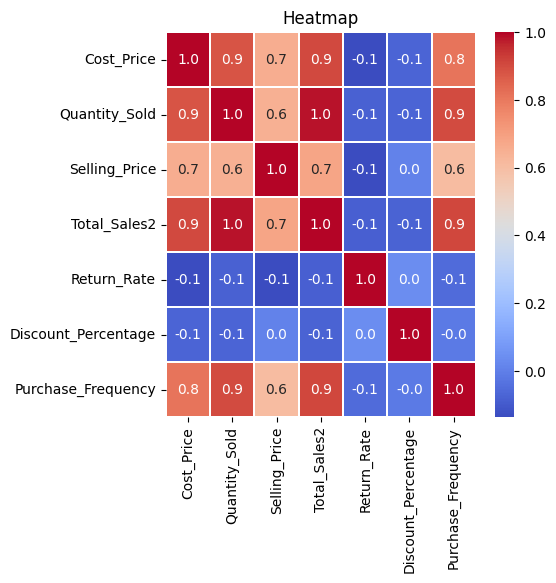

In [235]:
matrixcorr = dfjumpsuit[['Cost_Price', 'Quantity_Sold', 'Selling_Price','Total_Sales2', 'Return_Rate', 'Discount_Percentage','Purchase_Frequency']].corr()
plt.figure(figsize=(5,5))
sns.heatmap(matrixcorr, annot=True, cmap='coolwarm', fmt='.1f', linewidths=0.3)
plt.title('Heatmap')
plt.show()

# Findings - Pricing Strategy GAP


┌─────────────────────────────────────────────────────────────────┐
│           THE PRICING STRATEGY GAP                             │
└─────────────────────────────────────────────────────────────────┘

    Market Signal               Current Response     Desired Action
    ───────────                ───────────────      ──────────────
    
    "High-Cost = Premium"   →  "Treat All Sizes    →  Price by 
                                Equally"             Cost Tier + Demand"
                                
    Result:                 Result:                Result:
    ✓ Quality perception    ✗ Margin erosion       ✅ Profit capture
    
    High customer pull      Negative profitability  Optimized margins

# Target avg margin

In [203]:
dfjumpsuit.columns

Index(['Product_Category', 'Brand', 'Product_Name', 'Gender', 'Size', 'Color',
       'Season', 'Payment_Method', 'Customer_Type', 'Selling_Price',
       'Cost_Price', 'Discount_Percentage', 'Quantity_Sold', 'Total_Sales',
       'Stock_Availability', 'Customer_Age', 'Purchase_Frequency',
       'Store_Rating', 'Return_Rate', 'Sales_Category', 'Total_Cost',
       'Total_Sales2', 'Unit_Profit', 'Unit_Margin', 'Profit', 'Margin'],
      dtype='object')

In [247]:
dfjumpsuit

,Brand,Product_Name,Gender,Size,Color,Season,Selling_Price,Cost_Price,Unit_Profit,Unit_Margin,Discount_Percentage,Quantity_Sold,Total_Sales2,Total_Cost,Profit,Margin,Stock_Availability,Purchase_Frequency,Store_Rating,Return_Rate
554,Uniqlo,Jumpsuit,Men,M,Red,Winter,730.510854,947.195085,-216.684231,-0.296620,30.992702,8,4032.846407,7.577561e+03,-3544.714274,-0.878961,320.0,2.297425,4.662328,7.675874
2258,Uniqlo,Jumpsuit,Men,L,Green,Winter,963.061123,653.905363,309.155760,0.321014,2.189119,2,1883.957135,1.307811e+03,576.146409,0.305817,360.0,0.982576,4.836955,22.538473
2698,Uniqlo,Jumpsuit,Women,XXL,Orange,All-Season,1784.849623,457.291775,1327.557847,0.743793,38.447614,8,8788.940271,3.658334e+03,5130.606070,0.583757,477.0,1.790062,3.999342,16.391260
2706,Uniqlo,Jumpsuit,Women,L,Green,All-Season,1733.255375,907.581114,825.674262,0.476372,42.007029,4,4020.665137,3.630324e+03,390.340682,0.097084,414.0,4.045926,3.123513,12.911368
4010,Uniqlo,Jumpsuit,Men,S,Orange,Summer,1628.742593,731.852244,896.890349,0.550664,30.365818,8,9073.292607,5.854818e+03,3218.474654,0.354720,323.0,1.963553,4.781370,23.150711
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92277,Uniqlo,Jumpsuit,Women,S,Green,Winter,1537.895284,987.460835,550.434449,0.357914,42.242997,4,3552.968877,3.949843e+03,-396.874463,-0.111702,162.0,2.025231,4.054283,22.897270
96783,Uniqlo,Jumpsuit,Women,S,Blue,All-Season,963.360610,958.974248,4.386362,0.004553,14.773310,7,5747.282537,6.712820e+03,-965.537199,-0.167999,150.0,1.569700,3.048741,8.568299
96914,Uniqlo,Jumpsuit,Women,XL,Orange,All-Season,2169.986688,1541.030467,628.956221,0.289843,16.589154,5,9050.021310,7.705152e+03,1344.868973,0.148604,1.0,2.053450,3.743819,21.289311
99302,Uniqlo,Jumpsuit,Women,L,Green,Summer,1005.488670,609.370419,396.118251,0.393956,43.864303,6,3386.628427,3.656223e+03,-269.594089,-0.079605,21.0,4.009769,3.126922,29.544265


In [209]:
dfjumpsuit[(dfjumpsuit['Color']=='Blue')&(dfjumpsuit['Gender']=='Men')].sort_values('Season')

,Brand,Product_Name,Gender,Size,Color,Season,Selling_Price,Cost_Price,Unit_Profit,Unit_Margin,Discount_Percentage,Quantity_Sold,Total_Sales2,Total_Cost,Profit,Margin,Stock_Availability,Purchase_Frequency,Store_Rating,Return_Rate
16399,Uniqlo,Jumpsuit,Men,XL,Blue,All-Season,2151.613323,873.225764,1278.387559,0.594153,33.057538,6,8642.057559,5.239355e+03,3402.702975,0.393738,350.0,1.508859,4.140186,14.374847
31427,Uniqlo,Jumpsuit,Men,M,Blue,All-Season,2426.798806,1759.415226,667.383580,0.275006,22.034737,3,5676.180233,5.278246e+03,397.934555,0.070106,252.0,0.580087,3.155080,15.749780
24476,Uniqlo,Jumpsuit,Men,XXL,Blue,Summer,1561.438651,1621.953017,-60.514365,-0.038756,28.405184,1,1117.909137,1.621953e+03,-504.043880,-0.450881,88.0,1.311340,3.334645,12.123941
86728,Uniqlo,Jumpsuit,Men,L,Blue,Summer,1530.904386,1039.714727,491.189659,0.320849,22.589080,3,3555.261501,3.119144e+03,436.117321,0.122668,7.0,1.411331,4.428315,17.270947
7191,Uniqlo,Jumpsuit,Men,M,Blue,Winter,1262.032593,540.618242,721.414351,0.571629,5.486631,8,9542.316187,4.324946e+03,5217.370250,0.546761,65.0,3.478897,3.230666,17.340226
17753,Uniqlo,Jumpsuit,Men,M,Blue,Winter,845.058453,1066.319811,-221.261358,-0.261830,15.702337,6,4274.187164,6.397919e+03,-2123.731704,-0.496874,301.0,1.550095,4.423015,7.076632
26803,Uniqlo,Jumpsuit,Men,XL,Blue,Winter,1769.388863,696.100710,1073.288153,0.606587,40.780268,7,7334.791411,4.872705e+03,2462.086441,0.335672,422.0,1.537229,3.920719,23.896200
43889,Uniqlo,Jumpsuit,Men,M,Blue,Winter,1410.373737,1559.982584,-149.608847,-0.106077,42.082333,6,4901.133377,9.359896e+03,-4458.762126,-0.909741,40.0,1.538656,4.817872,5.761639
86356,Uniqlo,Jumpsuit,Men,XXL,Blue,Winter,1071.062581,1019.081098,51.981484,0.048533,46.854213,8,4553.797073,8.152649e+03,-3598.851708,-0.790297,10.0,0.920772,4.095682,10.029428
95453,Uniqlo,Jumpsuit,Men,M,Blue,Winter,2135.618959,814.406805,1321.212154,0.618655,38.720083,4,5234.822142,3.257627e+03,1977.194921,0.377700,203.0,2.387744,3.395116,6.892550


In [239]:
dfjumpsuit[dfjumpsuit['Unit_Profit']>0].pivot_table(
    columns=['Gender', 'Color', 'Season'], values=['Unit_Profit', 'Unit_Margin'], aggfunc=['mean']).reset_index()

index        mean                                       \
Gender                      Men                                        
Color                     Black                                 Blue   
Season               All-Season      Summer       Winter  All-Season   
0       Unit_Margin    0.474626    0.339194     0.640864    0.434579   
1       Unit_Profit  752.450225  754.856805  1007.337489  972.885570   

                                                                    \
Gender                                                               
Color                                Green                           
Season      Summer      Winter  All-Season      Summer      Winter   
0         0.320849    0.408916    0.260717    0.282949    0.468179   
1       491.189659  615.561329  255.868596  486.528918  642.222120   

                                                                     \
Gender                                                                
Color       Orange                                 Pink               
Season  All-Season      Summer      Winter   All-Season      Summer   
0         0.205190    0.340734    0.274698     0.598675    0.350690   
1       260.854504  568.071060  351.445394  1053.165619  612.127068   

                                                                       \
Gender                                                                  
Color                    Purple                                   Red   
Season       Winter  All-Season       Summer       Winter      Summer   
0          0.863190    0.409707     0.601749     0.587411    0.461576   
1       1712.673248  535.712145  1024.728543  1086.085304  705.201732   

                                                                      \
Gender                                                                 
Color                     White                               Yellow   
Season       Winter  All-Season      Summer      Winter   All-Season   
0          0.612855    0.171970    0.509636    0.706449     0.702078   
1       1380.163826  227.145161  698.823579  870.232747  1145.974533   

                                                                     \
Gender                                Women                           
Color                                 Black                           
Season       Summer      Winter  All-Season      Summer      Winter   
0          0.618908    0.499024    0.667362    0.134305    0.259108   
1       1407.725550  779.049767  769.083051  233.576323  601.620296   

                                                                     \
Gender                                                                
Color         Blue                    Green                           
Season  All-Season       Winter  All-Season      Summer      Winter   
0         0.222981     0.664904    0.476372    0.449361    0.399021   
1       442.336537  1204.647936  825.674262  518.346867  628.699872   

                                                                     \
Gender                                                                
Color       Orange                                 Pink               
Season  All-Season       Summer      Winter  All-Season      Summer   
0         0.598212     0.644715    0.410786    0.411932    0.536213   
1       968.720153  1166.072134  305.188935  667.104783  859.259637   

                                                                     \
Gender                                                                
Color                    Purple                                 Red   
Season      Winter   All-Season      Summer      Winter  All-Season   
0         0.359439     0.526924    0.244217    0.670091    0.548818   
1       545.713030  1035.871303  352.522953  966.902386  592.647037   

                                                                     \
Gender                                                                
Color      

In [244]:
dfjumpsuit[dfjumpsuit['Unit_Profit']>0].pivot_table(
    columns=['Gender', 'Color'], values=['Selling_Price'], aggfunc=['mean']).reset_index()

index         mean                                         \
Gender                         Men                                          
Color                        Black         Blue        Green       Orange   
0       Selling_Price  1809.922552  1701.966759  1367.009073  1475.280203   

                                                                         \
Gender                                                                    
Color          Pink       Purple          Red        White       Yellow   
0       1786.584817  1609.238937  1672.066897  1365.994919  1734.977584   

                                                                         \
Gender        Women                                                       
Color         Black         Blue        Green       Orange         Pink   
0       1624.342698  1738.249548  1445.231925  1512.887917  1565.530641   

                                                           
Gender                                                     
Color        Purple          Red       White       Yellow  
0       1485.150013  1440.188661  1732.55934  1427.171307

In [246]:
dfjumpsuit[dfjumpsuit['Unit_Profit']>0].pivot_table(
    columns=['Gender', 'Color'], values=['Discount_Percentage'], aggfunc=['mean']).reset_index()

index       mean                                   \
Gender                             Men                                    
Color                            Black       Blue      Green     Orange   
0       Discount_Percentage  34.422238  28.467078  25.391562  32.256143   

                                                                         \
Gender                                                            Women   
Color        Pink     Purple       Red      White     Yellow      Black   
0       25.405773  31.925638  17.19725  27.159739  34.626918  29.619101   

                                                                          \
Gender                                                                     
Color        Blue      Green     Orange       Pink     Purple        Red   
0       28.228922  25.362106  30.582238  22.423914  18.957386  26.299031   

                              
Gender                        
Color       White     Yellow  
0       24.462405  24.804871

In [242]:
# From the above table we can see Current min margin for Blue is 32%, generally for Winter is 40%.
# Let's take 32% first
Cost_BlueLMenWinter = 11867.523446	
Target_margin = 0.32
Minimum_Price = Cost_BlueLMenWinter / (1- Target_margin)
Minimum_Price

17452.240361764707

In [245]:
Average_price_of_Blue = 1701.966759
print(f'This min price {Minimum_Price / Average_price_of_Blue} higher than the average price')

This min price 10.254160528974648 higher than the average price


# Decide to remove Blue L from the sample dataset

In [251]:
dfjumpsuit = dfjumpsuit[~(
    (dfjumpsuit['Color']=='Blue')&(dfjumpsuit['Size']=='L')
           &(dfjumpsuit['Gender']=='Men')&(dfjumpsuit['Season']=='Winter')
           )]
print(dfjumpsuit.shape)
dfjumpsuit

(138, 20)


,Brand,Product_Name,Gender,Size,Color,Season,Selling_Price,Cost_Price,Unit_Profit,Unit_Margin,Discount_Percentage,Quantity_Sold,Total_Sales2,Total_Cost,Profit,Margin,Stock_Availability,Purchase_Frequency,Store_Rating,Return_Rate
554,Uniqlo,Jumpsuit,Men,M,Red,Winter,730.510854,947.195085,-216.684231,-0.296620,30.992702,8,4032.846407,7577.560681,-3544.714274,-0.878961,320.0,2.297425,4.662328,7.675874
2258,Uniqlo,Jumpsuit,Men,L,Green,Winter,963.061123,653.905363,309.155760,0.321014,2.189119,2,1883.957135,1307.810726,576.146409,0.305817,360.0,0.982576,4.836955,22.538473
2698,Uniqlo,Jumpsuit,Women,XXL,Orange,All-Season,1784.849623,457.291775,1327.557847,0.743793,38.447614,8,8788.940271,3658.334201,5130.606070,0.583757,477.0,1.790062,3.999342,16.391260
2706,Uniqlo,Jumpsuit,Women,L,Green,All-Season,1733.255375,907.581114,825.674262,0.476372,42.007029,4,4020.665137,3630.324455,390.340682,0.097084,414.0,4.045926,3.123513,12.911368
4010,Uniqlo,Jumpsuit,Men,S,Orange,Summer,1628.742593,731.852244,896.890349,0.550664,30.365818,8,9073.292607,5854.817952,3218.474654,0.354720,323.0,1.963553,4.781370,23.150711
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90292,Uniqlo,Jumpsuit,Men,L,Green,All-Season,981.402215,725.533619,255.868596,0.260717,12.129202,6,5174.195767,4353.201713,820.994054,0.158671,454.0,1.320022,4.875033,27.947798
92277,Uniqlo,Jumpsuit,Women,S,Green,Winter,1537.895284,987.460835,550.434449,0.357914,42.242997,4,3552.968877,3949.843340,-396.874463,-0.111702,162.0,2.025231,4.054283,22.897270
96783,Uniqlo,Jumpsuit,Women,S,Blue,All-Season,963.360610,958.974248,4.386362,0.004553,14.773310,7,5747.282537,6712.819736,-965.537199,-0.167999,150.0,1.569700,3.048741,8.568299
96914,Uniqlo,Jumpsuit,Women,XL,Orange,All-Season,2169.986688,1541.030467,628.956221,0.289843,16.589154,5,9050.021310,7705.152336,1344.868973,0.148604,1.0,2.053450,3.743819,21.289311


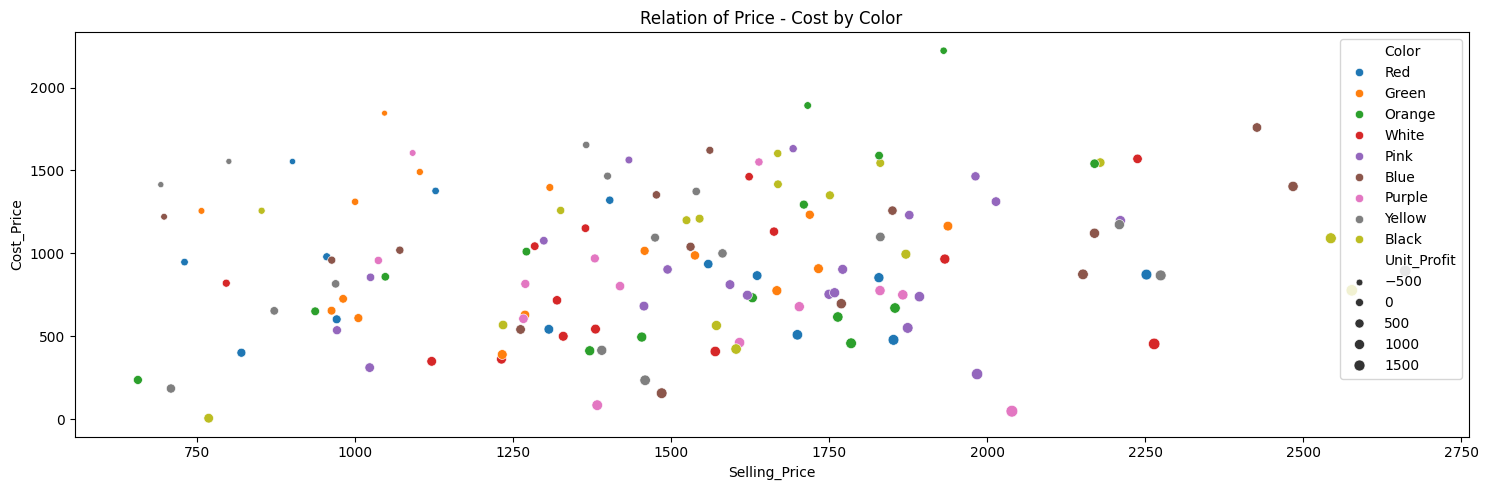

In [ ]:
plt.figure(figsize=(15,5))
ax = sns.scatterplot(data=dfjumpsuit, x='Selling_Price', y='Cost_Price',hue='Color', size='Unit_Profit')
ax.set_title('Relation of Price - Cost by Color')
plt.tight_layout()
plt.show()

In [259]:
# extract products with selling price <0
# dfjumpsuit.sort_values(by=['Gender','Color','Season', 'Size'])
dfjumpsuitneg = dfjumpsuit[(dfjumpsuit['Unit_Profit']<0)].sort_values(by=['Gender','Color','Season', 'Size'])
dfjumpsuitneg

,Brand,Product_Name,Gender,Size,Color,Season,Selling_Price,Cost_Price,Unit_Profit,Unit_Margin,Discount_Percentage,Quantity_Sold,Total_Sales2,Total_Cost,Profit,Margin,Stock_Availability,Purchase_Frequency,Store_Rating,Return_Rate
14796,Uniqlo,Jumpsuit,Men,XXL,Black,Winter,852.473956,1257.134298,-404.660342,-0.474689,48.788552,1,436.564257,1257.134298,-820.570041,-1.879609,4.0,3.973658,4.954486,4.507330
24476,Uniqlo,Jumpsuit,Men,XXL,Blue,Summer,1561.438651,1621.953017,-60.514365,-0.038756,28.405184,1,1117.909137,1621.953017,-504.043880,-0.450881,88.0,1.311340,3.334645,12.123941
72482,Uniqlo,Jumpsuit,Men,XL,Green,All-Season,1308.342072,1397.505199,-89.163126,-0.068150,31.857359,8,7132.310681,11180.041588,-4047.730907,-0.567520,46.0,1.482030,4.295080,27.311729
27326,Uniqlo,Jumpsuit,Men,S,Green,Summer,757.323713,1256.283871,-498.960158,-0.658847,10.085622,4,2723.771636,5025.135485,-2301.363848,-0.844918,418.0,1.973761,3.931283,7.079816
28192,Uniqlo,Jumpsuit,Men,M,Orange,Winter,1931.221132,2222.850811,-291.629679,-0.151008,5.914504,5,9084.994924,11114.254057,-2029.259133,-0.223364,58.0,2.250058,4.265689,0.952946
44326,Uniqlo,Jumpsuit,Men,XXL,Purple,Summer,1091.343058,1605.832783,-514.489726,-0.471428,1.233343,9,9700.947446,14452.495049,-4751.547603,-0.489802,66.0,1.761149,4.419603,24.551930
52338,Uniqlo,Jumpsuit,Men,L,Red,All-Season,1127.640278,1376.675371,-249.035093,-0.220846,31.003698,3,2334.090275,4130.026112,-1795.935838,-0.769437,383.0,0.927061,3.561125,20.356749
75811,Uniqlo,Jumpsuit,Men,XXL,Red,All-Season,955.469710,979.285344,-23.815635,-0.024926,30.819323,3,1983.001239,2937.856033,-954.854795,-0.481520,369.0,0.886163,3.415570,11.282557
554,Uniqlo,Jumpsuit,Men,M,Red,Winter,730.510854,947.195085,-216.684231,-0.296620,30.992702,8,4032.846407,7577.560681,-3544.714274,-0.878961,320.0,2.297425,4.662328,7.675874
58380,Uniqlo,Jumpsuit,Men,XXL,Yellow,All-Season,693.015914,1414.698928,-721.683014,-1.041366,25.562758,9,4642.757408,12732.290355,-8089.532946,-1.742398,172.0,4.449221,4.041980,9.404532


### Margin Loss

In [279]:
margin_loss = (dfjumpsuitneg['Selling_Price'].sum() - dfjumpsuitneg['Cost_Price'].sum()) * dfjumpsuitneg['Quantity_Sold'].sum()
print(f'for incorrect pricing, the revenue loss is {margin_loss}')

for incorrect pricing, the revenue loss is -847592.9968683363


### Current Profit Margin per Product

In [266]:
# calculate the avg, min, max of selling price
# join back to get the product negative profit
dfjumpsuitprice = pd.merge(left=dfjumpsuitneg[['Gender','Color','Season']].drop_duplicates(), right=dfjumpsuit, 
         on=['Gender','Color','Season'], how='inner').sort_values(['Gender','Season','Color', 'Size'])
dfjumpsuitprice

,Gender,Color,Season,Brand,Product_Name,Size,Selling_Price,Cost_Price,Unit_Profit,Unit_Margin,Discount_Percentage,Quantity_Sold,Total_Sales2,Total_Cost,Profit,Margin,Stock_Availability,Purchase_Frequency,Store_Rating,Return_Rate
5,Men,Green,All-Season,Uniqlo,Jumpsuit,L,981.402215,725.533619,255.868596,0.260717,12.129202,6,5174.195767,4353.201713,820.994054,0.158671,454.0,1.320022,4.875033,27.947798
4,Men,Green,All-Season,Uniqlo,Jumpsuit,XL,1308.342072,1397.505199,-89.163126,-0.068150,31.857359,8,7132.310681,11180.041588,-4047.730907,-0.567520,46.0,1.482030,4.295080,27.311729
13,Men,Red,All-Season,Uniqlo,Jumpsuit,L,1127.640278,1376.675371,-249.035093,-0.220846,31.003698,3,2334.090275,4130.026112,-1795.935838,-0.769437,383.0,0.927061,3.561125,20.356749
14,Men,Red,All-Season,Uniqlo,Jumpsuit,XXL,955.469710,979.285344,-23.815635,-0.024926,30.819323,3,1983.001239,2937.856033,-954.854795,-0.481520,369.0,0.886163,3.415570,11.282557
19,Men,Yellow,All-Season,Uniqlo,Jumpsuit,M,709.028744,184.245694,524.783051,0.740144,33.393874,5,2361.282887,921.228469,1440.054418,0.609861,319.0,2.554159,4.628485,19.435557
18,Men,Yellow,All-Season,Uniqlo,Jumpsuit,S,2661.341022,894.175007,1767.166015,0.664013,29.447329,3,5632.941561,2682.525021,2950.416541,0.523779,462.0,3.078636,4.932707,28.498517
17,Men,Yellow,All-Season,Uniqlo,Jumpsuit,XXL,693.015914,1414.698928,-721.683014,-1.041366,25.562758,9,4642.757408,12732.290355,-8089.532946,-1.742398,172.0,4.449221,4.041980,9.404532
3,Men,Blue,Summer,Uniqlo,Jumpsuit,L,1530.904386,1039.714727,491.189659,0.320849,22.589080,3,3555.261501,3119.144180,436.117321,0.122668,7.0,1.411331,4.428315,17.270947
2,Men,Blue,Summer,Uniqlo,Jumpsuit,XXL,1561.438651,1621.953017,-60.514365,-0.038756,28.405184,1,1117.909137,1621.953017,-504.043880,-0.450881,88.0,1.311340,3.334645,12.123941
6,Men,Green,Summer,Uniqlo,Jumpsuit,S,757.323713,1256.283871,-498.960158,-0.658847,10.085622,4,2723.771636,5025.135485,-2301.363848,-0.844918,418.0,1.973761,3.931283,7.079816


In [285]:
# Get current avg profit margin each color season
dfjumpsuit_avgmargin =dfjumpsuitprice[dfjumpsuitprice['Unit_Profit']>0].pivot_table(index=['Season','Gender', 'Color'], values='Unit_Margin', aggfunc='mean').reset_index()
dfjumpsuit_avgmargin


,Season,Gender,Color,Unit_Margin
0,All-Season,Men,Green,0.260717
1,All-Season,Men,Yellow,0.702078
2,All-Season,Women,Green,0.476372
3,All-Season,Women,Red,0.548818
4,All-Season,Women,Yellow,0.158503
5,Summer,Men,Blue,0.320849
6,Summer,Men,Green,0.282949
7,Summer,Men,Purple,0.601749
8,Summer,Men,Yellow,0.618908
9,Summer,Women,Green,0.449361


In [299]:
# get the average unit margin for each product line
dfjumpsuit_avgmargin2 = dfjumpsuitprice[['Gender','Season','Color']].drop_duplicates().merge(right=dfjumpsuit_avgmargin, on=['Gender','Season','Color'], how='left').sort_values(['Gender','Season','Color','Unit_Margin'])
dfjumpsuit_avgmargin2

,Gender,Season,Color,Unit_Margin
0,Men,All-Season,Green,0.260717
1,Men,All-Season,Red,NaN
2,Men,All-Season,Yellow,0.702078
3,Men,Summer,Blue,0.320849
4,Men,Summer,Green,0.282949
5,Men,Summer,Purple,0.601749
6,Men,Summer,Yellow,0.618908
7,Men,Winter,Black,0.640864
8,Men,Winter,Orange,0.274698
9,Men,Winter,Red,0.612855


In [300]:
# Identify indices of your NAs
na_indices = dfjumpsuit_avgmargin2[dfjumpsuit_avgmargin2['Unit_Margin'].isna()].index
na_indices

Index([1, 13], dtype='int64')

In [ ]:
# for WOMEN SUMMER BLUE because it has only Blue and Green so linear cannot be used, so use Green 
dfjumpsuit_avgmargin2.loc[na_indices[1], 'Unit_Margin'] = dfjumpsuit_avgmargin2['Unit_Margin'].bfill().loc[na_indices[1]]

# let's use linear filling na for MEN ALLSEASON READ because it is in same seris
dfjumpsuit_avgmargin2 = dfjumpsuit_avgmargin2.interpolate(method='linear')

dfjumpsuit_avgmargin2

C:\Users\minhtam.nguyen\AppData\Local\Temp\ipykernel_16284\3864400944.py:5: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  dfjumpsuit_avgmargin2 = dfjumpsuit_avgmargin2.interpolate(method='linear')


,Gender,Season,Color,Unit_Margin
0,Men,All-Season,Green,0.260717
1,Men,All-Season,Red,0.481398
2,Men,All-Season,Yellow,0.702078
3,Men,Summer,Blue,0.320849
4,Men,Summer,Green,0.282949
5,Men,Summer,Purple,0.601749
6,Men,Summer,Yellow,0.618908
7,Men,Winter,Black,0.640864
8,Men,Winter,Orange,0.274698
9,Men,Winter,Red,0.612855


### Recalculate the pricing based on the avg margin

In [305]:
dfjumpsuit_reprice = dfjumpsuitneg.merge(right=dfjumpsuit_avgmargin2, on=['Gender','Season','Color'], how='left', suffixes=("","_avg")).sort_values(['Gender','Season','Color'])
dfjumpsuit_reprice['Selling_Price_New'] = dfjumpsuit_reprice['Cost_Price'] / (1 - dfjumpsuit_reprice['Unit_Margin_avg'])
# dfjumpsuit_reprice['Total_Sales_New'] = (dfjumpsuit_reprice['Selling_Price_New'] - dfjumpsuit_reprice['Cost_Price']) * dfjumpsuit_reprice['Quantity_Sold']

dfjumpsuit_reprice['Price_Change'] = (dfjumpsuit_reprice['Selling_Price_New'] / dfjumpsuit_reprice['Selling_Price'] - 1) * 100
dfjumpsuit_reprice[['Brand', 'Product_Name', 'Gender', 'Size', 'Color', 'Season',
       'Selling_Price', 'Cost_Price', 'Unit_Profit', 'Unit_Margin',
       'Discount_Percentage', 'Quantity_Sold', 'Unit_Margin_avg', 'Selling_Price_New', 'Price_Change'
       ]]

,Brand,Product_Name,Gender,Size,Color,Season,Selling_Price,Cost_Price,Unit_Profit,Unit_Margin,Discount_Percentage,Quantity_Sold,Unit_Margin_avg,Selling_Price_New,Price_Change
2,Uniqlo,Jumpsuit,Men,XL,Green,All-Season,1308.342072,1397.505199,-89.163126,-0.068150,31.857359,8,0.260717,1890.353061,44.484619
6,Uniqlo,Jumpsuit,Men,L,Red,All-Season,1127.640278,1376.675371,-249.035093,-0.220846,31.003698,3,0.481398,2654.588935,135.410972
7,Uniqlo,Jumpsuit,Men,XXL,Red,All-Season,955.469710,979.285344,-23.815635,-0.024926,30.819323,3,0.481398,1888.317388,97.632365
9,Uniqlo,Jumpsuit,Men,XXL,Yellow,All-Season,693.015914,1414.698928,-721.683014,-1.041366,25.562758,9,0.702078,4748.562050,585.202454
1,Uniqlo,Jumpsuit,Men,XXL,Blue,Summer,1561.438651,1621.953017,-60.514365,-0.038756,28.405184,1,0.320849,2388.207960,52.949202
3,Uniqlo,Jumpsuit,Men,S,Green,Summer,757.323713,1256.283871,-498.960158,-0.658847,10.085622,4,0.282949,1752.014462,131.342876
5,Uniqlo,Jumpsuit,Men,XXL,Purple,Summer,1091.343058,1605.832783,-514.489726,-0.471428,1.233343,9,0.601749,4032.217651,269.472974
10,Uniqlo,Jumpsuit,Men,XXL,Yellow,Summer,800.652206,1554.898313,-754.246107,-0.942040,1.759761,9,0.618908,4080.116805,409.599146
0,Uniqlo,Jumpsuit,Men,XXL,Black,Winter,852.473956,1257.134298,-404.660342,-0.474689,48.788552,1,0.640864,3500.436771,310.620963
4,Uniqlo,Jumpsuit,Men,M,Orange,Winter,1931.221132,2222.850811,-291.629679,-0.151008,5.914504,5,0.274698,3064.722944,58.693528


In [304]:
dfjumpsuit_reprice.columns

Index(['Brand', 'Product_Name', 'Gender', 'Size', 'Color', 'Season',
       'Selling_Price', 'Cost_Price', 'Unit_Profit', 'Unit_Margin',
       'Discount_Percentage', 'Quantity_Sold', 'Total_Sales2', 'Total_Cost',
       'Profit', 'Margin', 'Stock_Availability', 'Purchase_Frequency',
       'Store_Rating', 'Return_Rate', 'Unit_Margin_avg', 'Selling_Price_New',
       'Total_Sales_New'],
      dtype='object')

# Another method - Elasticity

In [312]:
dfjumpsuit_elas = dfjumpsuitprice.groupby(by=['Gender','Season','Color']).agg(
    price_mean=('Selling_Price', 'mean'),
    price_min=('Selling_Price', 'min'),
    price_max=('Selling_Price', 'max'),
    qtysold_mean=('Quantity_Sold', 'mean'),
    qtysold_min=('Quantity_Sold', 'min'),
    qtysold_max=('Quantity_Sold', 'max'),
    ).reset_index()

# Implicit_Elasticity ≈ ΔQty/ Avg_Qty ÷ ΔSP / Avg_SP
#                     = (5000–6200)/5600 ÷ (85–80)/87.5
#                     = -0.21 / 0.057
#                     ≈ -3.7
dfjumpsuit_elas.eval(
    'implicit_elasticity = (qtysold_min - qtysold_max)/qtysold_mean / ((price_max - price_min)/price_mean)'
)

,Gender,Season,Color,price_mean,price_min,price_max,qtysold_mean,qtysold_min,qtysold_max,implicit_elasticity
0,Men,All-Season,Green,1144.872144,981.402215,1308.342072,7.000000,6,8,-1.000509
1,Men,All-Season,Red,1041.554994,955.469710,1127.640278,3.000000,3,3,0.000000
2,Men,All-Season,Yellow,1354.461894,693.015914,2661.341022,5.666667,3,9,-0.728607
3,Men,Summer,Blue,1546.171519,1530.904386,1561.438651,2.000000,1,3,-50.637259
4,Men,Summer,Green,1238.408780,757.323713,1719.493847,4.000000,4,4,0.000000
5,Men,Summer,Purple,1397.129303,1091.343058,1702.915549,5.000000,1,9,-3.655179
6,Men,Summer,Yellow,1537.590995,800.652206,2274.529785,7.000000,5,9,-0.596131
7,Men,Winter,Black,1212.158901,852.473956,1571.843846,2.500000,1,4,-2.022034
8,Men,Winter,Orange,1526.165825,937.176757,1931.221132,7.000000,5,9,-0.877320
9,Men,Winter,Red,1491.266832,730.510854,2252.022810,7.000000,6,8,-0.280035


# CONCLUSION

This dataset is not suitable for price evaluation and adjustment.
Reasons:
Huge outlier at specific size
Size S Cost > Size L (same spec)
Price Change Range: 24% to 500%
Applying Category Average Margin to Variants
Negative Margin Products Requiring Extreme Price Increases
